## checking uploads

In [1]:
import os
import glob

files = glob.glob("/content/*.csv")

for f in files:
    print(os.path.basename(f))

olist_order_reviews_dataset.csv
olist_order_items_dataset.csv
olist_geolocation_dataset.csv
olist_sellers_dataset.csv
olist_products_dataset.csv
olist_customers_dataset.csv
olist_orders_dataset.csv
product_category_name_translation.csv
olist_order_payments_dataset.csv


## Auditing and cleaning data

### checking NULLs among primary keys

In [2]:
import pandas as pd
import os

primary_keys = {
    "olist_orders_dataset.csv": ["order_id"],
    "olist_order_items_dataset.csv": ["order_id", "order_item_id"],
    "olist_order_payments_dataset.csv": ["order_id", "payment_sequential"],
    "olist_order_reviews_dataset.csv": ["review_id"],
    "olist_customers_dataset.csv": ["customer_id"],
    "olist_products_dataset.csv": ["product_id"],
    "olist_sellers_dataset.csv": ["seller_id"],
    "product_category_name_translation.csv": ["product_category_name"]
}

for file, keys in primary_keys.items():
    path = f"/content/{file}"
    df = pd.read_csv(path)

    print(f"\n{file}")

    for key in keys:
        null_count = df[key].isna().sum()
        print(f"  {key}: {null_count} NULLs")


olist_orders_dataset.csv
  order_id: 0 NULLs



olist_order_items_dataset.csv
  order_id: 0 NULLs
  order_item_id: 0 NULLs



olist_order_payments_dataset.csv
  order_id: 0 NULLs
  payment_sequential: 0 NULLs



olist_order_reviews_dataset.csv
  review_id: 0 NULLs



olist_customers_dataset.csv
  customer_id: 0 NULLs

olist_products_dataset.csv
  product_id: 0 NULLs

olist_sellers_dataset.csv
  seller_id: 0 NULLs

product_category_name_translation.csv
  product_category_name: 0 NULLs


### check if foreign keys are orphaned

In [3]:
import pandas as pd

# Load the relevant tables
orders = pd.read_csv("/content/olist_orders_dataset.csv")
customers = pd.read_csv("/content/olist_customers_dataset.csv")
order_items = pd.read_csv("/content/olist_order_items_dataset.csv")
payments = pd.read_csv("/content/olist_order_payments_dataset.csv")
reviews = pd.read_csv("/content/olist_order_reviews_dataset.csv")
products = pd.read_csv("/content/olist_products_dataset.csv")
sellers = pd.read_csv("/content/olist_sellers_dataset.csv")
categories = pd.read_csv("/content/product_category_name_translation.csv")


def check_fk(child_df, child_col, parent_df, parent_col, relationship):
    child_values = child_df[child_col].dropna()
    parent_values = set(parent_df[parent_col].dropna())
    orphaned = child_values[~child_values.isin(parent_values)]
    print(f"\n{relationship}")
    print(f"  Child rows checked : {len(child_values):,}")
    print(f"  Orphaned values   : {len(orphaned):,}")

    if len(orphaned) > 0:
        print(f"  Unique orphaned IDs: {orphaned.nunique():,}")
        print("  Examples:", orphaned.unique()[:10])


#orphan checks
# orders → customers
check_fk(orders,"customer_id",customers,"customer_id","orders.customer_id → customers.customer_id")

# order_items → orders
check_fk(order_items,"order_id",orders,"order_id","order_items.order_id → orders.order_id")

# order_items → products
check_fk(order_items,"product_id",products,"product_id","order_items.product_id → products.product_id")

# order_items → sellers
check_fk(order_items,"seller_id",sellers,"seller_id","order_items.seller_id → sellers.seller_id")

# payments → orders
check_fk(payments,"order_id", orders, "order_id","order_payments.order_id → orders.order_id")

# reviews → orders
check_fk(reviews,"order_id",orders,"order_id","order_reviews.order_id → orders.order_id")

# products → category translation
check_fk(products,"product_category_name",categories,"product_category_name","products.product_category_name → category_translation.product_category_name")


orders.customer_id → customers.customer_id
  Child rows checked : 99,441
  Orphaned values   : 0

order_items.order_id → orders.order_id
  Child rows checked : 112,650
  Orphaned values   : 0

order_items.product_id → products.product_id
  Child rows checked : 112,650
  Orphaned values   : 0

order_items.seller_id → sellers.seller_id
  Child rows checked : 112,650
  Orphaned values   : 0

order_payments.order_id → orders.order_id
  Child rows checked : 103,886
  Orphaned values   : 0



order_reviews.order_id → orders.order_id
  Child rows checked : 99,224
  Orphaned values   : 0

products.product_category_name → category_translation.product_category_name
  Child rows checked : 32,341
  Orphaned values   : 13
  Unique orphaned IDs: 2
  Examples: <StringArray>
['pc_gamer', 'portateis_cozinha_e_preparadores_de_alimentos']
Length: 2, dtype: str


### primary key uniqueness

In [4]:
for file, keys in primary_keys.items():
    df = pd.read_csv(f"/content/{file}")
    duplicate_count = df.duplicated(subset=keys).sum()
    print(f"{file}")
    print(f"  Duplicate PK rows: {duplicate_count:,}")
    if duplicate_count > 0:
        print("\n  Example duplicates:")
        print(df[df.duplicated(subset=keys, keep=False)].sort_values(keys).head(10))
    print()

olist_orders_dataset.csv
  Duplicate PK rows: 0



olist_order_items_dataset.csv
  Duplicate PK rows: 0

olist_order_payments_dataset.csv
  Duplicate PK rows: 0



olist_order_reviews_dataset.csv
  Duplicate PK rows: 814

  Example duplicates:
                              review_id                          order_id  \
46678  00130cbe1f9d422698c812ed8ded1919  dfcdfc43867d1c1381bfaf62d6b9c195   
29841  00130cbe1f9d422698c812ed8ded1919  04a28263e085d399c97ae49e0b477efa   
90677  0115633a9c298b6a98bcbe4eee75345f  78a4201f58af3463bdab842eea4bc801   
63193  0115633a9c298b6a98bcbe4eee75345f  0c9850b2c179c1ef60d2855e2751d1fa   
92876  0174caf0ee5964646040cd94e15ac95e  f93a732712407c02dce5dd5088d0f47b   
57280  0174caf0ee5964646040cd94e15ac95e  74db91e33b4e1fd865356c89a61abf1f   
54832  017808d29fd1f942d97e50184dfb4c13  8daaa9e99d60fbba579cc1c3e3bfae01   
99167  017808d29fd1f942d97e50184dfb4c13  b1461c8882153b5fe68307c46a506e39   
20621  0254bd905dc677a6078990aad3331a36  5bf226cf882c5bf4247f89a97c86f273   
96080  0254bd905dc677a6078990aad3331a36  331b367bdd766f3d1cf518777317b5d9   

       review_score review_comment_title  \
46678             1         

It seems like many customers have left reviews for different orders with the same review ID..

In [5]:
print(
    "Duplicate (review_id, order_id) pairs:",
    reviews.duplicated(
        subset=["review_id", "order_id"]
    ).sum()
)

Duplicate (review_id, order_id) pairs: 0


Clearly this is true.. no 2 review_id order_id pairs have been duplicated

In [6]:
reviews = pd.read_csv("/content/olist_order_reviews_dataset.csv")
# How many unique review IDs?
print("Total rows:", len(reviews))
print("Unique review IDs:", reviews["review_id"].nunique())
# Distribution of number of rows per review_id
counts = reviews.groupby("review_id").size()
print("\nReview IDs occurring multiple times:")
print(counts.value_counts().sort_index())
print("\nMaximum occurrences of a single review_id:", counts.max())

Total rows: 99224
Unique review IDs: 98410

Review IDs occurring multiple times:
1    97621
2      764
3       25
Name: count, dtype: int64

Maximum occurrences of a single review_id: 3


In [7]:
duplicate_orders = reviews[reviews.duplicated("order_id", keep=False)].sort_values("order_id")
print(duplicate_orders.size)
print(duplicate_orders.head(20).to_string(index=False))

7686
                       review_id                         order_id  review_score review_comment_title                                                                                                                                                                 review_comment_message review_creation_date review_answer_timestamp
89a02c45c340aeeb1354a24e7d4b2c1e 0035246a40f520710769010f752e7507             5                  NaN                                                                                                                                                                                    NaN  2017-08-29 00:00:00     2017-08-30 01:59:12
2a74b0559eb58fc1ff842ecc999594cb 0035246a40f520710769010f752e7507             5                  NaN                                                            Estou acostumada a comprar produtos pelo baratheon. Super confiável, transparência, qualidade e agilidade. Super recomendo.  2017-08-25 00:00:00     2017-08-29 21:45:57
ab30810c

clearly order IDs are not unique either as one order may have multiple products and each product may have different reviews. So the takeaway would be to make the pair (review_Id, order_Id) the primary key. joins won't be an issue as review_ID does not appear anywhere else


### Check exact duplicate rows

In [8]:
import pandas as pd
import glob
import os

for file in sorted(glob.glob("/content/*.csv")):
    df = pd.read_csv(file)
    duplicate_rows = df.duplicated().sum()
    print(f"{os.path.basename(file)}")
    print(f"  Exact duplicate rows: {duplicate_rows:,}")

olist_customers_dataset.csv
  Exact duplicate rows: 0


olist_geolocation_dataset.csv
  Exact duplicate rows: 0


olist_order_items_dataset.csv
  Exact duplicate rows: 0
olist_order_payments_dataset.csv
  Exact duplicate rows: 0


olist_order_reviews_dataset.csv
  Exact duplicate rows: 0


olist_orders_dataset.csv
  Exact duplicate rows: 0
olist_products_dataset.csv
  Exact duplicate rows: 0
olist_sellers_dataset.csv
  Exact duplicate rows: 0
product_category_name_translation.csv
  Exact duplicate rows: 0


removing duplicate rows in geolocation table

In [9]:
import pandas as pd
file_path = "/content/olist_geolocation_dataset.csv"
df = pd.read_csv(file_path)
df = df.drop_duplicates()
df.to_csv(file_path, index=False)

In [10]:
df = pd.read_csv(file_path)
print(df.duplicated().sum())

0


### Check for missing values other than those already talked about in the data quality notes

Data Quality Notes (from problem statement pasted for rreference)

Unlike a synthetic dataset, these are genuine characteristics of real operational data, not issues inserted for the exercise. They are exactly the kind of thing a working analyst has to notice and handle:

- **order_status is not always delivered:** 96,478 of 99,441 orders are delivered; the remainder are shipped, canceled, unavailable, invoiced, processing, created, or approved, and most of these lack complete delivery timestamps by nature. Decide deliberately how to treat non-delivered orders in any delivery-time analysis.
- **Missing timestamps:** order_approved_at is missing for 160 orders, order_delivered_carrier_date for 1,783 orders, and order_delivered_customer_date for 2,965 orders, consistent with orders that never completed the normal fulfillment flow.
- **customer_id versus customer_unique_id:** customer_id is unique per order (99,441 unique values, one per order); customer_unique_id identifies the same person across multiple orders and has only 96,096 unique values, meaning several thousand people placed more than one order. This distinction is easy to miss and directly affects any repeat-customer analysis.
- **Multi-item and multi-payment orders:** 13,984 orders have more than one order_items row, and 4,446 orders have more than one order_payments row. Naive row counts on these tables will not equal the number of orders; aggregate deliberately.
- **Missing product information:** 610 products are missing category name and related listing detail fields, and 2 products are missing weight and dimension fields.
- **Mostly-empty review text:** 88,285 of 100,000 reviews have no comment title, and 58,247 have no comment message. Most customers rate without writing anything; text-based analysis is optional and will only apply to a minority of reviews.
- **Geolocation is not a clean lookup table:** 1,000,163 rows cover roughly 19,000 unique zip code prefixes, so joining directly without aggregating first will multiply rows unexpectedly.
- **No injected issues:** there are no artificially inserted duplicates, sign errors, or missing-value patterns in this dataset. Every quirk described here is a real characteristic of the original Olist export.

In [11]:
import pandas as pd
import glob
import os

for file in sorted(glob.glob("/content/*.csv")):
    df = pd.read_csv(file)
    missing = df.isna().sum()
    missing = missing[missing > 0]
    print(f"\n{'='*70}")
    print(os.path.basename(file))
    if missing.empty:
        print("No missing values.")
    else:
        for col, count in missing.items():
            print(f"{col:45} {count:>8,}")


olist_customers_dataset.csv
No missing values.



olist_geolocation_dataset.csv
No missing values.

olist_order_items_dataset.csv
No missing values.



olist_order_payments_dataset.csv
No missing values.



olist_order_reviews_dataset.csv
review_comment_title                            87,656
review_comment_message                          58,247



olist_orders_dataset.csv
order_approved_at                                  160
order_delivered_carrier_date                     1,783
order_delivered_customer_date                    2,965

olist_products_dataset.csv
product_category_name                              610
product_name_lenght                                610
product_description_lenght                         610
product_photos_qty                                 610
product_weight_g                                     2
product_length_cm                                    2
product_height_cm                                    2
product_width_cm                                     2

olist_sellers_dataset.csv
No missing values.

product_category_name_translation.csv
No missing values.


clearly no missing values other than the ones given in the notes

## Creating an SQLite database

In [12]:
import sqlite3
db_path = "/content/olist.db"
conn = sqlite3.connect(db_path)
# Enforce foreign-key constraints
conn.execute("PRAGMA foreign_keys = ON;")
print("Database created:", db_path)

Database created: /content/olist.db


In [13]:
conn.executescript("""
DROP TABLE IF EXISTS order_reviews;
DROP TABLE IF EXISTS order_payments;
DROP TABLE IF EXISTS order_items;
DROP TABLE IF EXISTS orders;
DROP TABLE IF EXISTS customers;
DROP TABLE IF EXISTS products;
DROP TABLE IF EXISTS sellers;
DROP TABLE IF EXISTS geolocation;
DROP TABLE IF EXISTS category_translation;

CREATE TABLE customers (
    customer_id TEXT PRIMARY KEY,
    customer_unique_id TEXT NOT NULL,
    customer_zip_code_prefix INTEGER NOT NULL,
    customer_city TEXT NOT NULL,
    customer_state TEXT NOT NULL
);

CREATE TABLE sellers (
    seller_id TEXT PRIMARY KEY,
    seller_zip_code_prefix INTEGER NOT NULL,
    seller_city TEXT NOT NULL,
    seller_state TEXT NOT NULL
);

CREATE TABLE category_translation (
    product_category_name TEXT PRIMARY KEY,
    product_category_name_english TEXT NOT NULL
);

CREATE TABLE products (
    product_id TEXT PRIMARY KEY,
    product_category_name TEXT,
    product_name_lenght INTEGER,
    product_description_lenght INTEGER,
    product_photos_qty INTEGER,
    product_weight_g REAL,
    product_length_cm REAL,
    product_height_cm REAL,
    product_width_cm REAL
);

CREATE TABLE orders (
    order_id TEXT PRIMARY KEY,
    customer_id TEXT NOT NULL,
    order_status TEXT NOT NULL,
    order_purchase_timestamp TEXT NOT NULL,
    order_approved_at TEXT,
    order_delivered_carrier_date TEXT,
    order_delivered_customer_date TEXT,
    order_estimated_delivery_date TEXT,

    FOREIGN KEY (customer_id)
        REFERENCES customers(customer_id)
);

CREATE TABLE order_items (
    order_id TEXT NOT NULL,
    order_item_id INTEGER NOT NULL,
    product_id TEXT NOT NULL,
    seller_id TEXT NOT NULL,
    shipping_limit_date TEXT NOT NULL,
    price REAL NOT NULL,
    freight_value REAL NOT NULL,

    PRIMARY KEY (order_id, order_item_id),

    FOREIGN KEY (order_id)
        REFERENCES orders(order_id),

    FOREIGN KEY (product_id)
        REFERENCES products(product_id),

    FOREIGN KEY (seller_id)
        REFERENCES sellers(seller_id)
);

CREATE TABLE order_payments (
    order_id TEXT NOT NULL,
    payment_sequential INTEGER NOT NULL,
    payment_type TEXT NOT NULL,
    payment_installments INTEGER NOT NULL,
    payment_value REAL NOT NULL,

    PRIMARY KEY (order_id, payment_sequential),

    FOREIGN KEY (order_id)
        REFERENCES orders(order_id)
);

CREATE TABLE order_reviews (
    review_id TEXT NOT NULL,
    order_id TEXT NOT NULL,
    review_score INTEGER NOT NULL,
    review_comment_title TEXT,
    review_comment_message TEXT,
    review_creation_date TEXT NOT NULL,
    review_answer_timestamp TEXT NOT NULL,

    PRIMARY KEY (review_id, order_id),

    FOREIGN KEY (order_id)
        REFERENCES orders(order_id)
);

CREATE TABLE geolocation (
    geolocation_zip_code_prefix INTEGER NOT NULL,
    geolocation_lat REAL NOT NULL,
    geolocation_lng REAL NOT NULL,
    geolocation_city TEXT,
    geolocation_state TEXT
);
""")

conn.commit()

print("All 9 tables created successfully.")

All 9 tables created successfully.


loading the tables

In [14]:
import pandas as pd

csv_to_table = {
    "olist_customers_dataset.csv": "customers",
    "olist_sellers_dataset.csv": "sellers",
    "product_category_name_translation.csv": "category_translation",
    "olist_products_dataset.csv": "products",
    "olist_orders_dataset.csv": "orders",
    "olist_order_items_dataset.csv": "order_items",
    "olist_order_payments_dataset.csv": "order_payments",
    "olist_order_reviews_dataset.csv": "order_reviews",
    "olist_geolocation_dataset.csv": "geolocation"
}

for csv_file, table in csv_to_table.items():
    path = f"/content/{csv_file}"
    df = pd.read_csv(path)
    # Convert NaN to None so SQLite stores them as NULL
    df = df.where(pd.notna(df), None)
    df.to_sql(
        table,
        conn,
        if_exists="append",
        index=False
    )
    print(f"{table:25} {len(df):>10,} rows")

conn.commit()

customers                     99,441 rows
sellers                        3,095 rows
category_translation              71 rows
products                      32,951 rows


orders                        99,441 rows


order_items                  112,650 rows


order_payments               103,886 rows


order_reviews                 99,224 rows


geolocation                  738,332 rows


In [15]:
reviews = pd.read_csv(
    "/content/olist_order_reviews_dataset.csv",
    dtype={"review_score": "string"},
    low_memory=False
)

print(reviews["review_score"].value_counts(dropna=False))

review_score
5    57328
4    19142
1    11424
3     8179
2     3151
Name: count, dtype: Int64


In [16]:
print("Foreign-key violations:")
print(conn.execute("PRAGMA foreign_key_check;").fetchall())

print("\nDatabase integrity:")
print(conn.execute("PRAGMA integrity_check;").fetchone()[0])

Foreign-key violations:


[]

Database integrity:


ok


## ER diagram

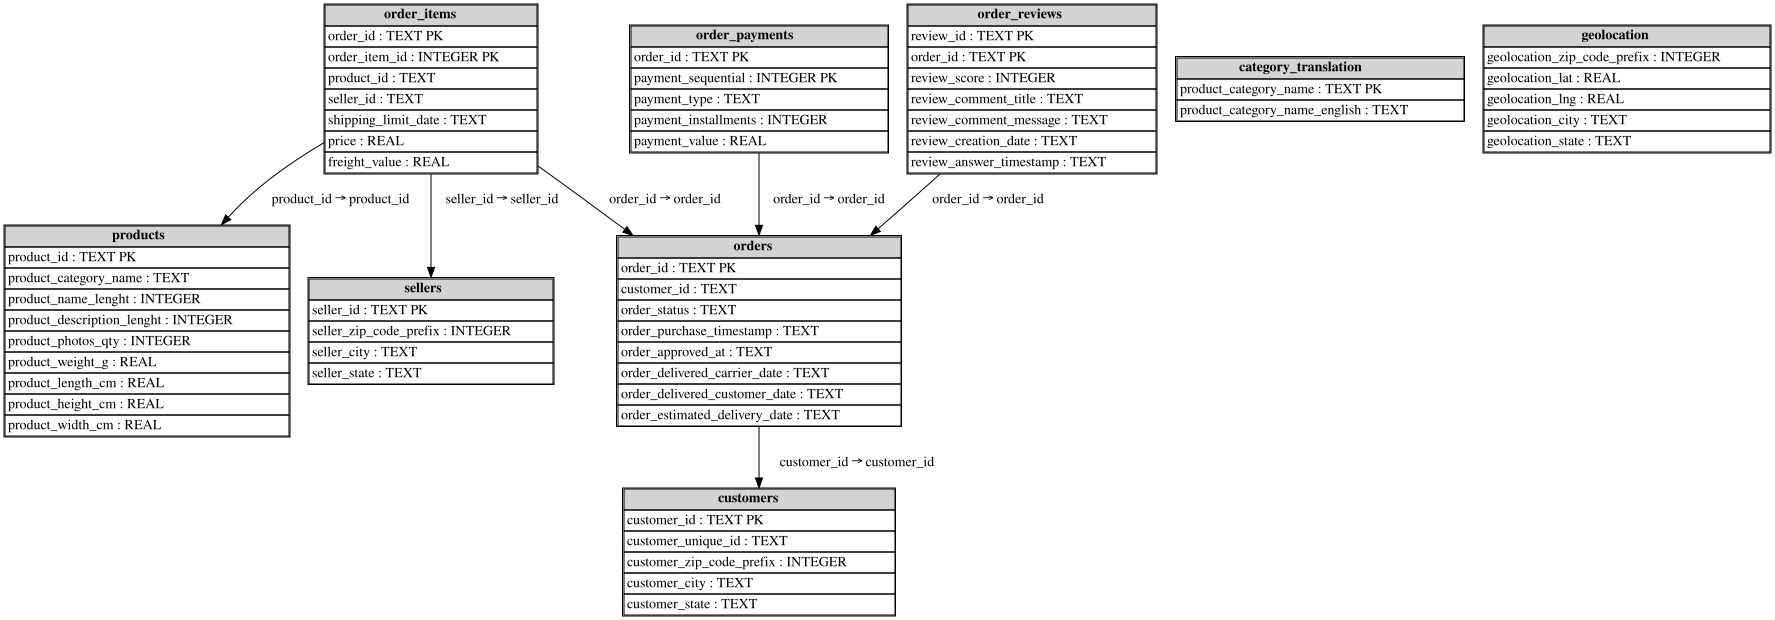

In [17]:
from graphviz import Digraph

dot = Digraph("ER_Diagram", format="png")

tables = [
    "customers",
    "orders",
    "order_items",
    "order_payments",
    "order_reviews",
    "products",
    "sellers",
    "category_translation",
    "geolocation"
]

# Add tables and their columns
for table in tables:
    columns = conn.execute(f"PRAGMA table_info({table})").fetchall()

    label = f"<<TABLE BORDER='1' CELLBORDER='1' CELLSPACING='0'>"
    label += f"<TR><TD BGCOLOR='lightgray'><B>{table}</B></TD></TR>"

    for col in columns:
        cid, name, dtype, notnull, default, pk = col

        key = " PK" if pk else ""
        label += f"<TR><TD ALIGN='LEFT'>{name} : {dtype}{key}</TD></TR>"

    label += "</TABLE>>"

    dot.node(table, label=label, shape="plain")


# Add actual foreign-key relationships
for table in tables:
    foreign_keys = conn.execute(
        f"PRAGMA foreign_key_list({table})"
    ).fetchall()

    for fk in foreign_keys:
        # SQLite PRAGMA foreign_key_list:
        # (id, seq, table, from, to, on_update, on_delete, match, ...)
        referenced_table = fk[2]
        from_column = fk[3]
        to_column = fk[4]

        dot.edge(
            table,
            referenced_table,
            label=f"{from_column} → {to_column}"
        )

dot

## Core questions analysis

Question-1 Marketplace Performance Over Time: How have order volume, revenue, and review scores trended across the available time period? Do they all tell the same story?

Creating tables with different time discretisations

for the given interval of time, i'll analyse over months for trend

In [18]:
query = """
WITH order_revenue AS (
    SELECT
        order_id,
        SUM(price + freight_value) AS revenue
    FROM order_items
    GROUP BY order_id
),

order_reviews_agg AS (
    SELECT
        order_id,
        AVG(review_score) AS avg_review_score
    FROM order_reviews
    GROUP BY order_id
)

SELECT
    strftime('%Y-%m', o.order_purchase_timestamp) AS month,
    COUNT(DISTINCT o.order_id) AS order_volume,
    SUM(COALESCE(orv.revenue, 0)) AS revenue,
    AVG(r.avg_review_score) AS avg_review_score
FROM orders AS o
LEFT JOIN order_revenue AS orv
    ON o.order_id = orv.order_id
LEFT JOIN order_reviews_agg AS r
    ON o.order_id = r.order_id
GROUP BY month
ORDER BY month;
"""

result_over_months = pd.read_sql_query(query, conn)

Plots over months

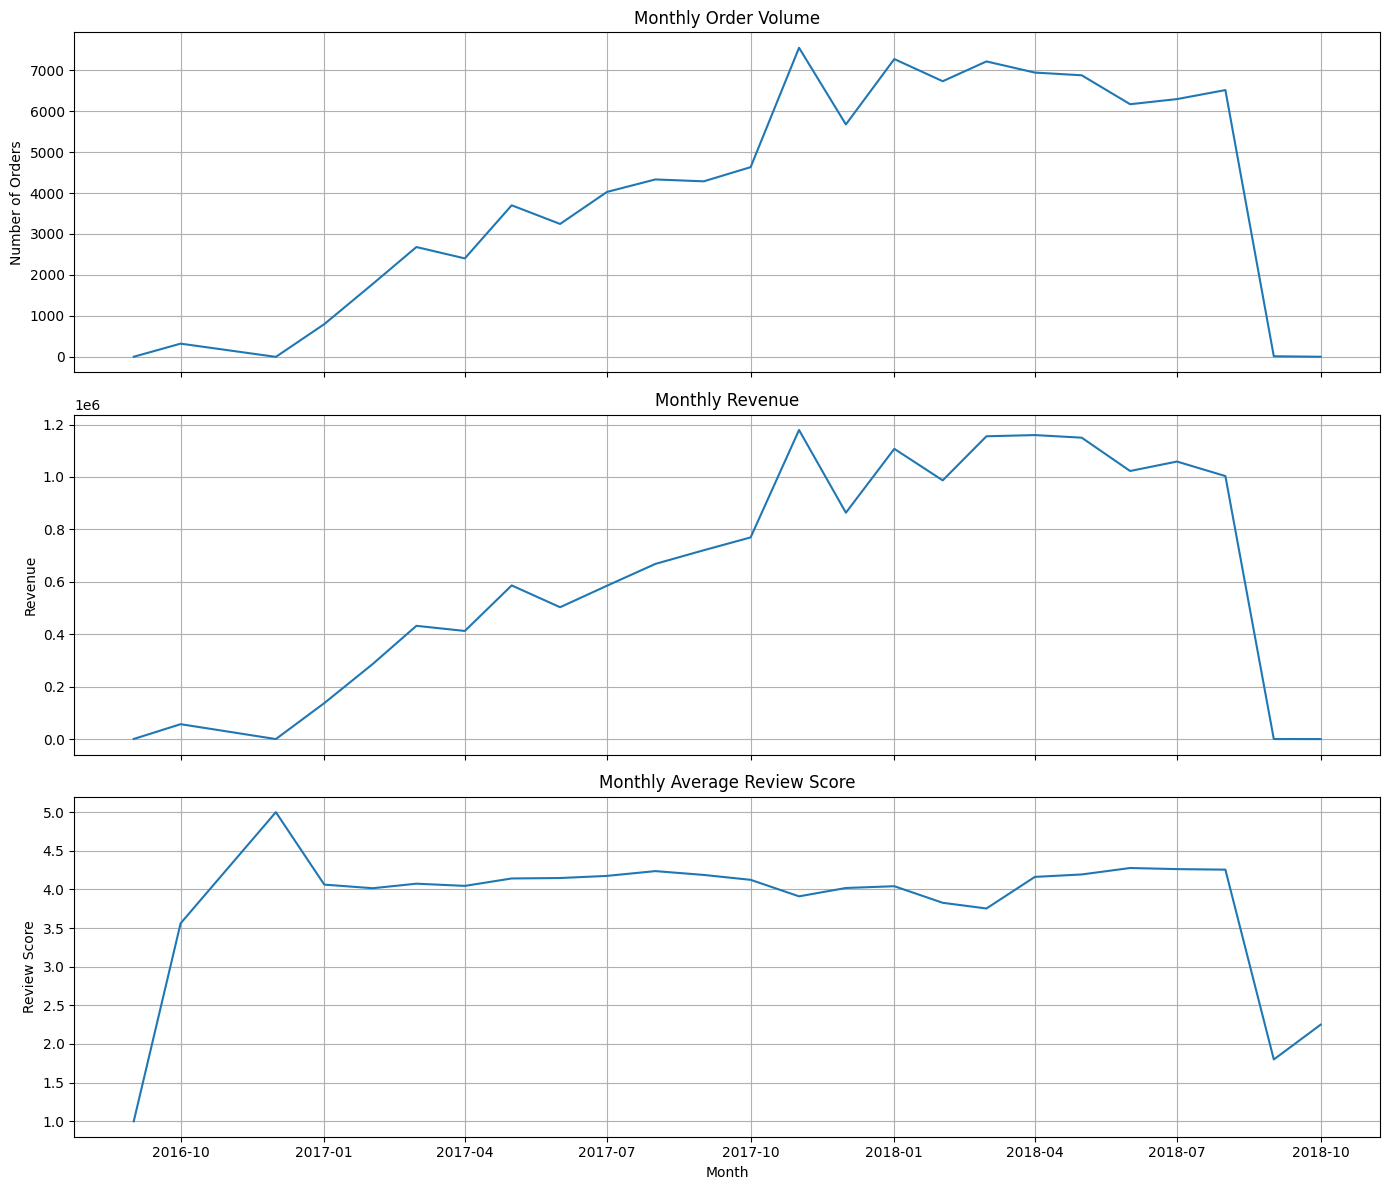

In [19]:
import matplotlib.pyplot as plt

result_over_months["month"] = pd.to_datetime(
    result_over_months["month"]
)

fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True)

# Order volume
axes[0].plot(
    result_over_months["month"],
    result_over_months["order_volume"]
)
axes[0].set_title("Monthly Order Volume")
axes[0].set_ylabel("Number of Orders")
axes[0].grid(True)

# Revenue
axes[1].plot(
    result_over_months["month"],
    result_over_months["revenue"]
)
axes[1].set_title("Monthly Revenue")
axes[1].set_ylabel("Revenue")
axes[1].grid(True)

# Review score
axes[2].plot(
    result_over_months["month"],
    result_over_months["avg_review_score"]
)
axes[2].set_title("Monthly Average Review Score")
axes[2].set_ylabel("Review Score")
axes[2].set_xlabel("Month")
axes[2].grid(True)

plt.tight_layout()
plt.show()

In [20]:
result_over_months["order_volume_ma"] = (
    result_over_months["order_volume"]
    .rolling(3)
    .mean()
)

result_over_months["revenue_ma"] = (
    result_over_months["revenue"]
    .rolling(3)
    .mean()
)

result_over_months["review_score_ma"] = (
    result_over_months["avg_review_score"]
    .rolling(3)
    .mean()
)

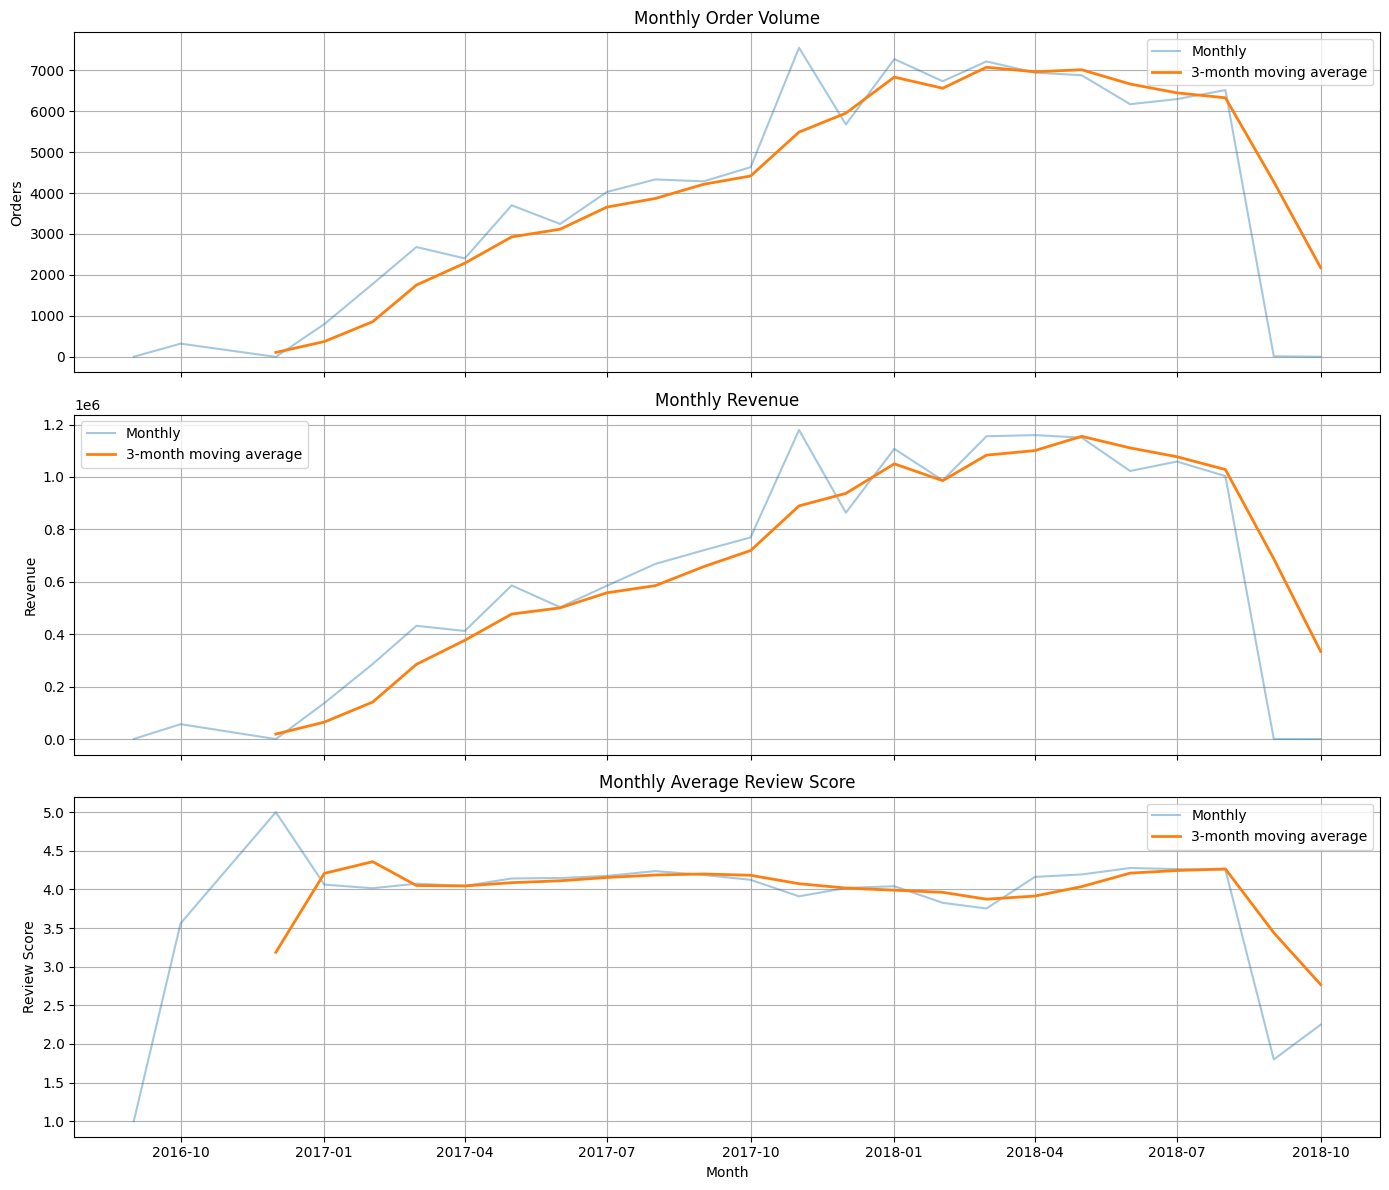

In [21]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True)

# Orders
axes[0].plot(
    result_over_months["month"],
    result_over_months["order_volume"],
    alpha=0.4,
    label="Monthly"
)
axes[0].plot(
    result_over_months["month"],
    result_over_months["order_volume_ma"],
    linewidth=2,
    label="3-month moving average"
)
axes[0].set_title("Monthly Order Volume")
axes[0].set_ylabel("Orders")
axes[0].legend()
axes[0].grid(True)

# Revenue
axes[1].plot(
    result_over_months["month"],
    result_over_months["revenue"],
    alpha=0.4,
    label="Monthly"
)
axes[1].plot(
    result_over_months["month"],
    result_over_months["revenue_ma"],
    linewidth=2,
    label="3-month moving average"
)
axes[1].set_title("Monthly Revenue")
axes[1].set_ylabel("Revenue")
axes[1].legend()
axes[1].grid(True)

# Reviews
axes[2].plot(
    result_over_months["month"],
    result_over_months["avg_review_score"],
    alpha=0.4,
    label="Monthly"
)
axes[2].plot(
    result_over_months["month"],
    result_over_months["review_score_ma"],
    linewidth=2,
    label="3-month moving average"
)
axes[2].set_title("Monthly Average Review Score")
axes[2].set_ylabel("Review Score")
axes[2].set_xlabel("Month")
axes[2].legend()
axes[2].grid(True)

plt.tight_layout()
plt.show()

Trend: Orders and revenue grew substantially over the observation period, with growth slowing/flattening during 2018.

Relationship: Revenue closely follows order volume, suggesting the increase in revenue is primarily associated with increased marketplace activity.

Customer experience: Review scores remain relatively stable around 4+, despite the substantial growth in marketplace activity. Thus, higher volume did not correspond to a comparable deterioration in customer ratings.

Conclusion: Orders and revenue tell a broadly similar story; review scores tell a different one. Therefore, marketplace scale increased considerably without a major long-term change in average customer satisfaction.

### Question 2 : Delivery Performance and Customer Satisfaction:
How does delivery timing (relative to the estimated delivery date) relate to review scores? Does this hold across different categories and regions, or is it concentrated somewhere specific?

A parameter estimating delivery delays would be helpful

In [22]:
query = """
SELECT
    o.order_id,
    o.order_delivered_customer_date,
    o.order_estimated_delivery_date,
    r.review_score,
    julianday(o.order_delivered_customer_date)
        - julianday(o.order_estimated_delivery_date) AS delivery_delay_days
FROM orders AS o
JOIN order_reviews AS r
    ON o.order_id = r.order_id
WHERE o.order_delivered_customer_date IS NOT NULL
  AND o.order_estimated_delivery_date IS NOT NULL
  AND r.review_score IS NOT NULL;
"""

delivery_reviews = pd.read_sql_query(query, conn)

delivery_reviews.head()

,order_id,order_delivered_customer_date,order_estimated_delivery_date,review_score,delivery_delay_days
0,73fc7af87114b39712e6da79b0a377eb,2018-01-17 18:42:41,2018-02-02 00:00:00,4,-15.220359
1,a548910a1c6147796b98fdf73dbeba33,2018-03-09 23:17:20,2018-03-14 00:00:00,5,-4.029630
2,f9e4b658b201a9f2ecdecbb34bed034b,2018-02-16 17:28:48,2018-03-09 00:00:00,5,-20.271667
3,658677c97b385a9be170737859d3511b,2017-04-20 09:08:35,2017-05-10 00:00:00,5,-19.619039
4,8e6bfb81e283fa7e4f11123a3fb894f1,2018-02-28 16:33:35,2018-03-09 00:00:00,5,-8.310012


measuring correlations

In [23]:
delivery_reviews["delay_group"] = pd.cut(
    delivery_reviews["delivery_delay_days"],
    bins=[-1000, -15, -7, -1, 0, 3, 7, 15, 30, 1000],
    labels=[
        "< -15 days",
        "-15 to -8",
        "-7 to -1",
        "On time",
        "1–3 days late",
        "4–7 days late",
        "8–15 days late",
        "16–30 days late",
        "> 30 days late"
    ]
)

delay_review = (
    delivery_reviews
    .groupby("delay_group", observed=True)
    .agg(
        avg_review_score=("review_score", "mean"),
        order_count=("order_id", "nunique")
    )
    .reset_index()
)

delay_review

,delay_group,avg_review_score,order_count
0,< -15 days,4.317425,29458
1,-15 to -8,4.315536,41476
2,-7 to -1,4.204199,15784
3,On time,4.153054,1450
4,1–3 days late,3.765372,2636
5,4–7 days late,2.316263,1773
6,8–15 days late,1.735996,1918
7,16–30 days late,1.622000,992
8,> 30 days late,2.023188,343


/tmp/ipykernel_513/2607939817.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='delay_group', y='avg_review_score', data=delay_review, palette='viridis')


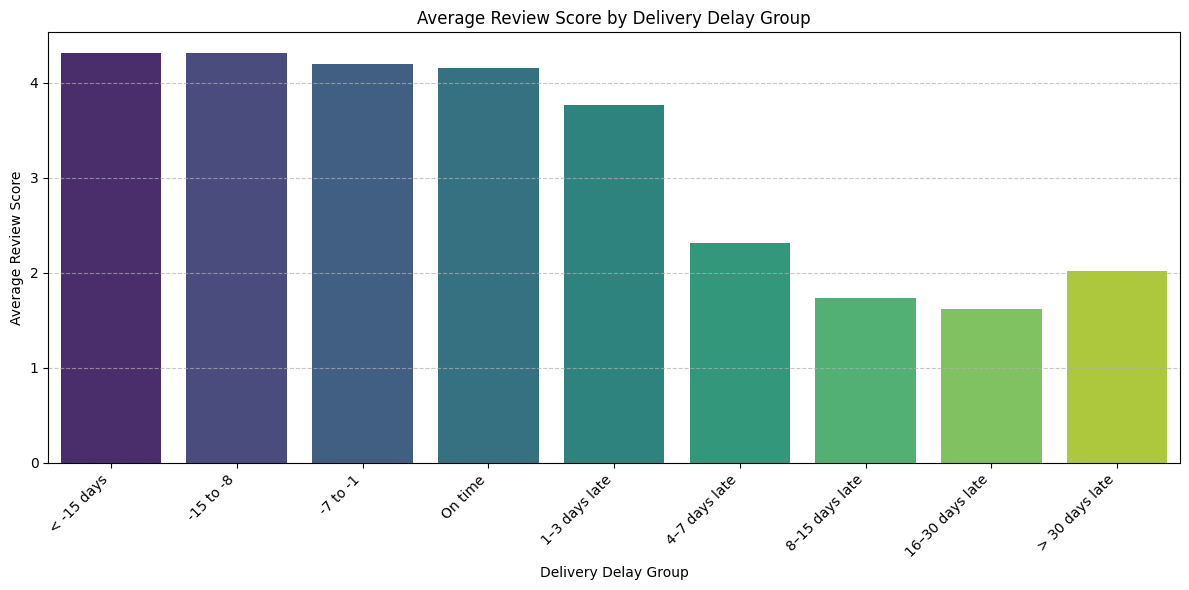

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))
sns.barplot(x='delay_group', y='avg_review_score', data=delay_review, palette='viridis')
plt.title('Average Review Score by Delivery Delay Group')
plt.xlabel('Delivery Delay Group')
plt.ylabel('Average Review Score')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [25]:
print(
    "Pearson:",
    delivery_reviews["delivery_delay_days"].corr(
        delivery_reviews["review_score"],
        method="pearson"
    )
)

print(
    "Spearman:",
    delivery_reviews["delivery_delay_days"].corr(
        delivery_reviews["review_score"],
        method="spearman"
    )
)

Pearson: -0.2664140261726979
Spearman: -0.1756117420557752


"Delivery lateness is negatively associated with review scores, but the association is relatively weak at the individual-order level (Spearman ρ = −0.176). Nevertheless, grouped averages show a pronounced decline in ratings for substantially delayed deliveries, suggesting that severe delays are associated with poorer customer satisfaction."

### Question 3 : Seller and Geographic Patterns:
 Sellers and customers are not evenly distributed across Brazil. How does this geographic pattern relate to delivery performance, freight cost, or customer satisfaction?

Mapping zip prefixes to unique co ordinates

In [26]:
query = """
SELECT
    geolocation_zip_code_prefix,
    AVG(geolocation_lat) AS lat,
    AVG(geolocation_lng) AS lng
FROM geolocation
GROUP BY geolocation_zip_code_prefix;
"""

zip_coords = pd.read_sql_query(query, conn)

zip_coords.head()

,geolocation_zip_code_prefix,lat,lng
0,1001,-23.550227,-46.634039
1,1002,-23.547657,-46.634991
2,1003,-23.549000,-46.635582
3,1004,-23.549829,-46.634792
4,1005,-23.549547,-46.636406


mapping zip co ordinates to customers

In [27]:
query = """
SELECT
    c.customer_id,
    c.customer_zip_code_prefix,
    z.lat AS customer_lat,
    z.lng AS customer_lng
FROM customers AS c
LEFT JOIN (
    SELECT
        geolocation_zip_code_prefix,
        AVG(geolocation_lat) AS lat,
        AVG(geolocation_lng) AS lng
    FROM geolocation
    GROUP BY geolocation_zip_code_prefix
) AS z
ON c.customer_zip_code_prefix = z.geolocation_zip_code_prefix;
"""

customer_coords = pd.read_sql_query(query, conn)

mapping zip co ordinates to sellers

In [28]:
query = """
SELECT
    s.seller_id,
    s.seller_zip_code_prefix,
    z.lat AS seller_lat,
    z.lng AS seller_lng
FROM sellers AS s
LEFT JOIN (
    SELECT
        geolocation_zip_code_prefix,
        AVG(geolocation_lat) AS lat,
        AVG(geolocation_lng) AS lng
    FROM geolocation
    GROUP BY geolocation_zip_code_prefix
) AS z
ON s.seller_zip_code_prefix = z.geolocation_zip_code_prefix;
"""

seller_coords = pd.read_sql_query(query, conn)

calculating grodesic distances between zip codes using the haversine formula

In [29]:
from geopy.distance import geodesic

In [30]:
import numpy as np

def haversine(lat1, lon1, lat2, lon2):
    R = 6371.0
    lat1 = np.radians(lat1)
    lon1 = np.radians(lon1)
    lat2 = np.radians(lat2)
    lon2 = np.radians(lon2)
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = (np.sin(dlat / 2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2)**2)
    return 2 * R * np.arcsin(np.sqrt(a))

In [31]:
query = """
SELECT
    oi.order_id,
    oi.order_item_id,
    oi.seller_id,
    oi.price,
    oi.freight_value,
    c.customer_id
FROM order_items AS oi
JOIN orders AS o
    ON oi.order_id = o.order_id
JOIN customers AS c
    ON o.customer_id = c.customer_id;
"""

items_geo = pd.read_sql_query(query, conn)
items_geo = (items_geo.merge(seller_coords, on="seller_id", how="left").merge(customer_coords, on="customer_id", how="left"))

In [32]:
items_geo["distance_km"] = haversine(
    items_geo["seller_lat"],
    items_geo["seller_lng"],
    items_geo["customer_lat"],
    items_geo["customer_lng"]
)

measuring correlation coefficient of distances against freight values

In [33]:
items_geo[["distance_km", "freight_value"]].corr(method="pearson")

,distance_km,freight_value
distance_km,1.00000,0.38938
freight_value,0.38938,1.00000


plotting geodesic distance against freight

In [34]:
items_geo["distance_group"] = pd.cut(
    items_geo["distance_km"],
    bins=[0, 100, 250, 500, 1000, 2000, 4000, np.inf],
    labels=[
        "<100 km",
        "100–250 km",
        "250–500 km",
        "500–1000 km",
        "1000–2000 km",
        "2000–4000 km",
        ">4000 km"
    ]
)

distance_freight = (
    items_geo
    .groupby("distance_group", observed=True)
    .agg(
        avg_freight=("freight_value", "mean"),
        median_freight=("freight_value", "median"),
        order_items=("order_id", "count")
    ).reset_index()
)

distance_freight

,distance_group,avg_freight,median_freight,order_items
0,<100 km,11.749816,9.34,20967
1,100–250 km,15.874129,13.41,10941
2,250–500 km,19.252720,15.86,32390
3,500–1000 km,21.148189,17.74,30076
4,1000–2000 km,29.201185,22.72,11268
5,2000–4000 km,35.909628,28.85,6423
6,>4000 km,32.594000,29.24,5


/tmp/ipykernel_513/382625463.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='distance_group', y='avg_freight', data=distance_freight, palette='viridis', ax=ax)


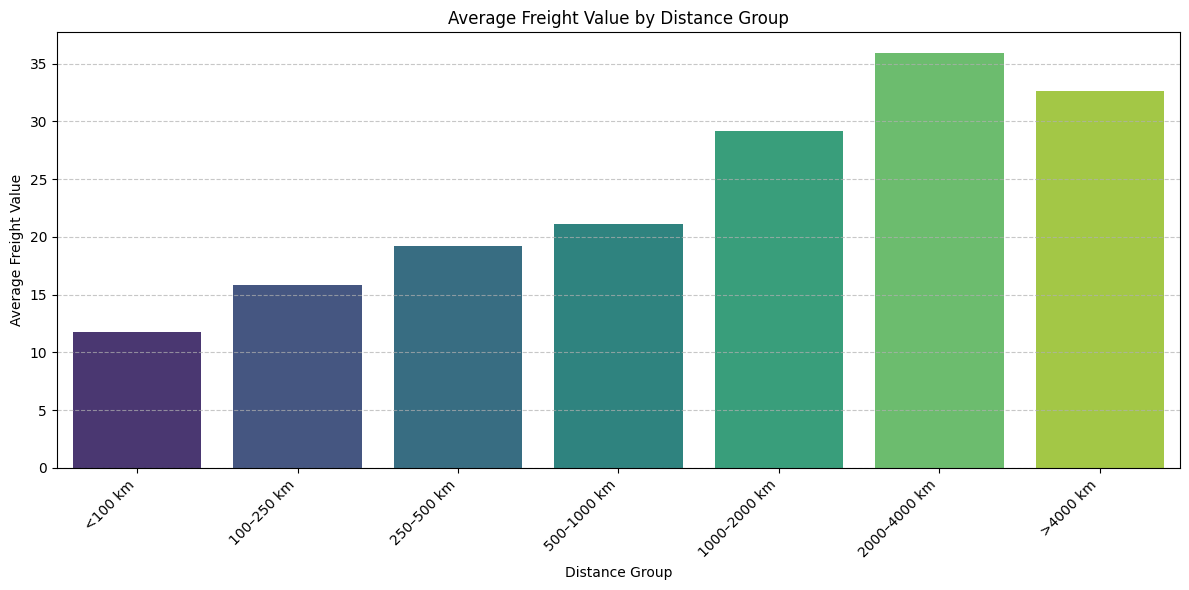

In [35]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot Average Freight Value by Distance Group
fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(x='distance_group', y='avg_freight', data=distance_freight, palette='viridis', ax=ax)
plt.title('Average Freight Value by Distance Group')
plt.xlabel('Distance Group')
plt.ylabel('Average Freight Value')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

/tmp/ipykernel_513/2164310400.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='distance_group', y='median_freight', data=distance_freight, palette='magma', ax=ax)


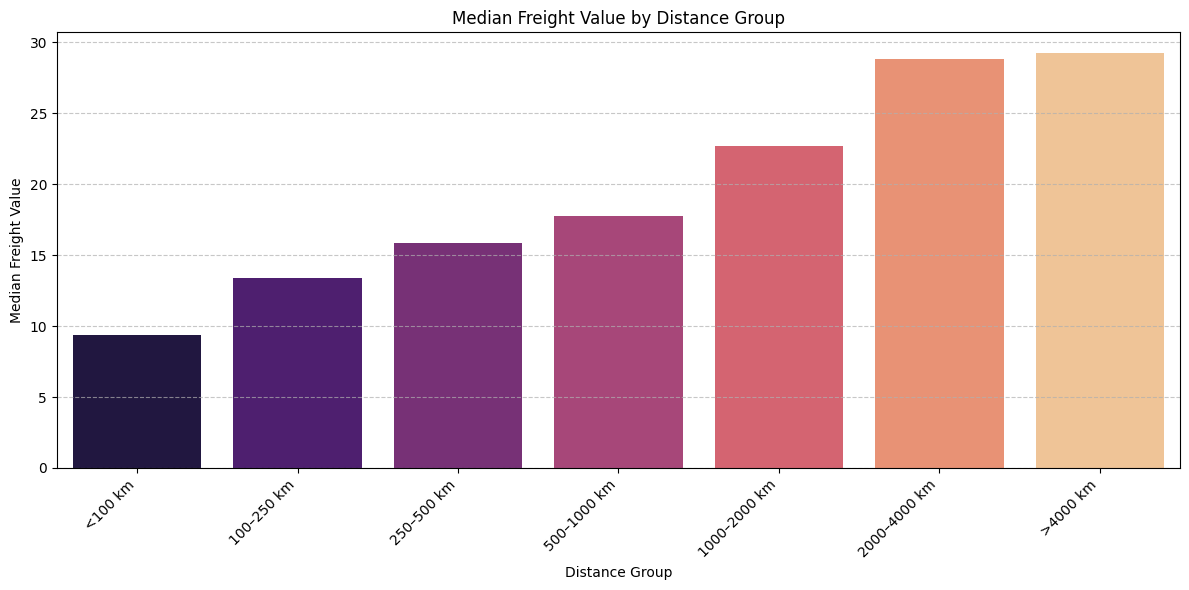

In [36]:
# Plot Median Freight Value by Distance Group
fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(x='distance_group', y='median_freight', data=distance_freight, palette='magma', ax=ax)
plt.title('Median Freight Value by Distance Group')
plt.xlabel('Distance Group')
plt.ylabel('Median Freight Value')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

clearly a monotonically increasing relation exists between distance and freight values

calculating avg delivery delay

In [37]:
query = """
SELECT
    o.order_id,
    o.customer_id,
    julianday(o.order_delivered_customer_date)
        - julianday(o.order_estimated_delivery_date)
        AS delivery_delay_days
FROM orders AS o
WHERE o.order_delivered_customer_date IS NOT NULL
  AND o.order_estimated_delivery_date IS NOT NULL;
"""

delivery = pd.read_sql_query(query, conn)

order_distance = items_geo.groupby("order_id").agg(
    distance_km=("distance_km", "max")
).reset_index()

delivery = delivery.merge(
    order_distance,
    on="order_id",
    how="inner"
)

In [38]:
delivery["distance_group"] = pd.cut(
    delivery["distance_km"],
    bins=[0, 100, 250, 500, 1000, 2000, 4000, np.inf],
    labels=[
        "<100 km",
        "100–250 km",
        "250–500 km",
        "500–1000 km",
        "1000–2000 km",
        "2000–4000 km",
        ">4000 km"
    ]
)

delivery_by_distance = (
    delivery
    .groupby("distance_group", observed=True)
    .agg(
        avg_delay=("delivery_delay_days", "mean"),
        median_delay=("delivery_delay_days", "median"),
        orders=("order_id", "count")
    )
    .reset_index()
)

delivery_by_distance

,distance_group,avg_delay,median_delay,orders
0,<100 km,-8.787616,-8.342587,17776
1,100–250 km,-10.709244,-11.066510,9360
2,250–500 km,-11.603647,-12.289375,27611
3,500–1000 km,-12.010515,-13.095816,25828
4,1000–2000 km,-12.169504,-13.221597,9775
5,2000–4000 km,-12.017480,-13.257847,5623
6,>4000 km,-4.309933,-6.391962,4


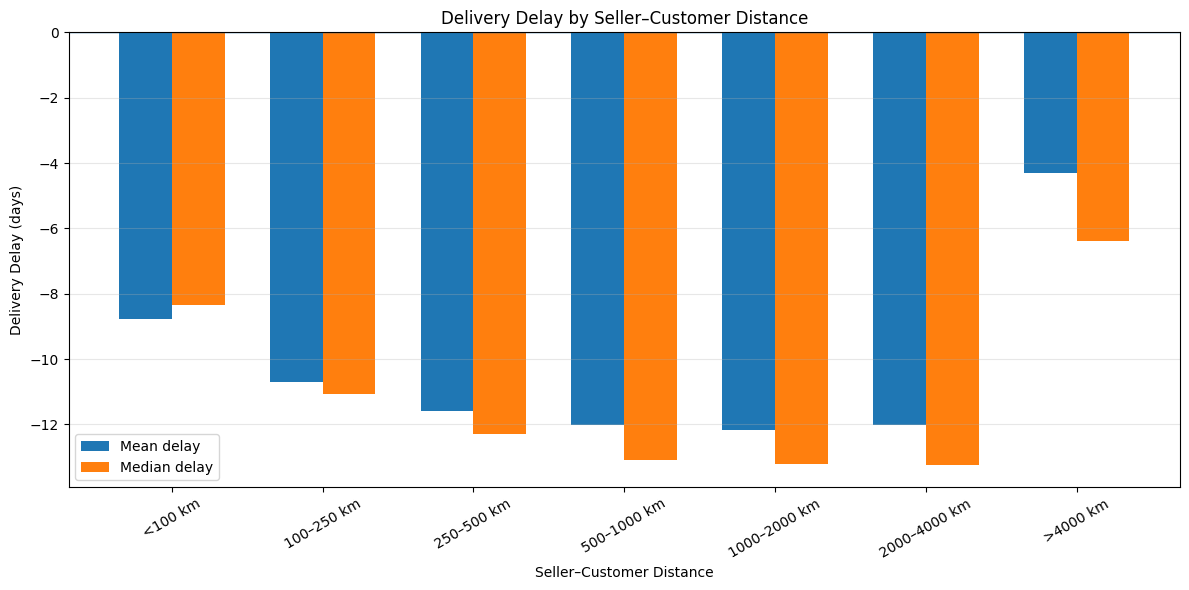

In [39]:
plt.figure(figsize=(12, 6))

x = np.arange(len(delivery_by_distance["distance_group"]))
width = 0.35

plt.bar(
    x - width/2,
    delivery_by_distance["avg_delay"],
    width,
    label="Mean delay"
)

plt.bar(
    x + width/2,
    delivery_by_distance["median_delay"],
    width,
    label="Median delay"
)

plt.axhline(0, linewidth=1)

plt.xlabel("Seller–Customer Distance")
plt.ylabel("Delivery Delay (days)")
plt.title("Delivery Delay by Seller–Customer Distance")

plt.xticks(
    x,
    delivery_by_distance["distance_group"],
    rotation=30
)

plt.legend()
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

distance v/s customer satisfaction

Geographic distance has a strong relationship with freight cost, but this does not mean poorer delivery performance or proportionaly lower customer satisfaction. Despite higher freight costs for longer seller cstomer distances, deliveries generally occurred before the estimated date across all distance groups

distance v/s reviews

In [40]:
distance_reviews = (
    delivery_reviews
    .merge(order_distance, on="order_id", how="inner")
    .assign(
        distance_group=lambda x: pd.cut(
            x["distance_km"],
            bins=[0, 100, 250, 500, 1000, 2000, 4000, np.inf],
            labels=[
                "<100 km",
                "100–250 km",
                "250–500 km",
                "500–1000 km",
                "1000–2000 km",
                "2000–4000 km",
                ">4000 km"
            ]
        )
    )
    .groupby("distance_group", observed=True)
    .agg(
        avg_review=("review_score", "mean"),
        median_review=("review_score", "median"),
        orders=("order_id", "nunique")
    )
    .reset_index()
)


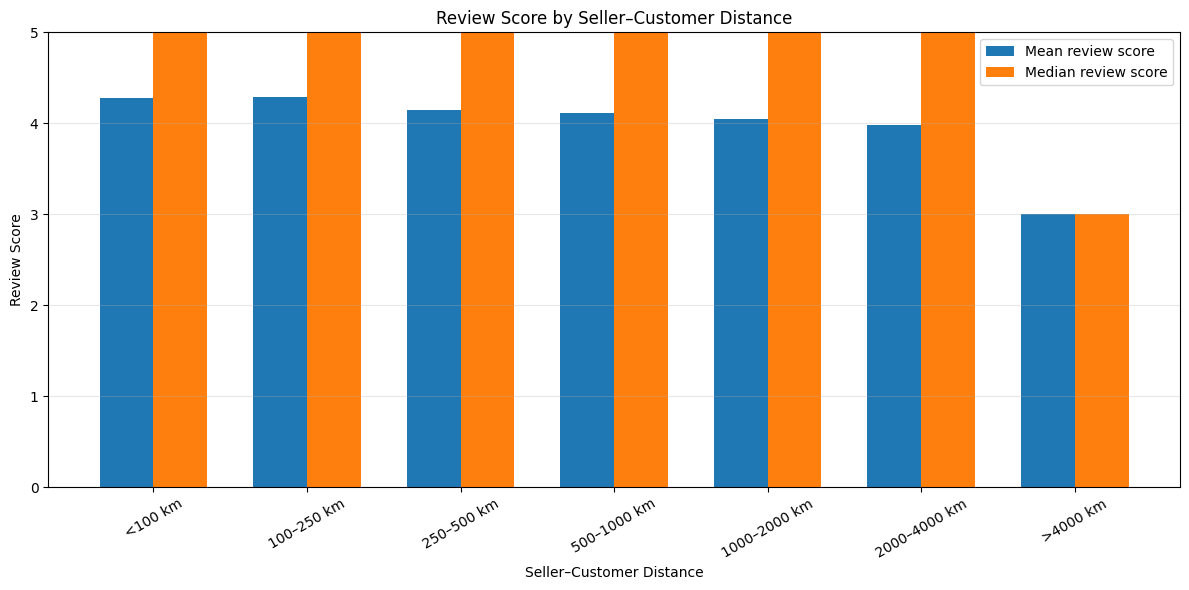

In [41]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(12, 6))

x = np.arange(len(distance_reviews["distance_group"]))
width = 0.35

plt.bar(
    x - width/2,
    distance_reviews["avg_review"],
    width,
    label="Mean review score"
)

plt.bar(
    x + width/2,
    distance_reviews["median_review"],
    width,
    label="Median review score"
)

plt.xlabel("Seller–Customer Distance")
plt.ylabel("Review Score")
plt.title("Review Score by Seller–Customer Distance")

plt.xticks(
    x,
    distance_reviews["distance_group"],
    rotation=30
)

plt.ylim(0, 5)
plt.legend()
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

Geographic distance has a modest relationship with customer satisfaction, with average review scores generally declining as seller–customer distance increases. However, the decline is relatively small across the main distance groups, suggesting that longer shipping distances do not proportionally translate into lower customer satisfaction.

Final conclusions

Geographic distance is strongly associated with freight costs, with average freight increasing substantially as seller–customer distance grows. However, greater distance does not appear to worsen delivery performance relative to the estimated delivery date: deliveries were generally completed several days ahead of the estimate across all distance groups. Customer satisfaction shows a modest decline with increasing distance, with average review scores falling from approximately 4.27 for shipments under 100 km to 3.98 for shipments between 2,000 and 4,000 km. Thus, geographic distance has a pronounced effect on shipping cost but only a relatively modest association with customer satisfaction, while delivery performance relative to estimated dates remains broadly strong.

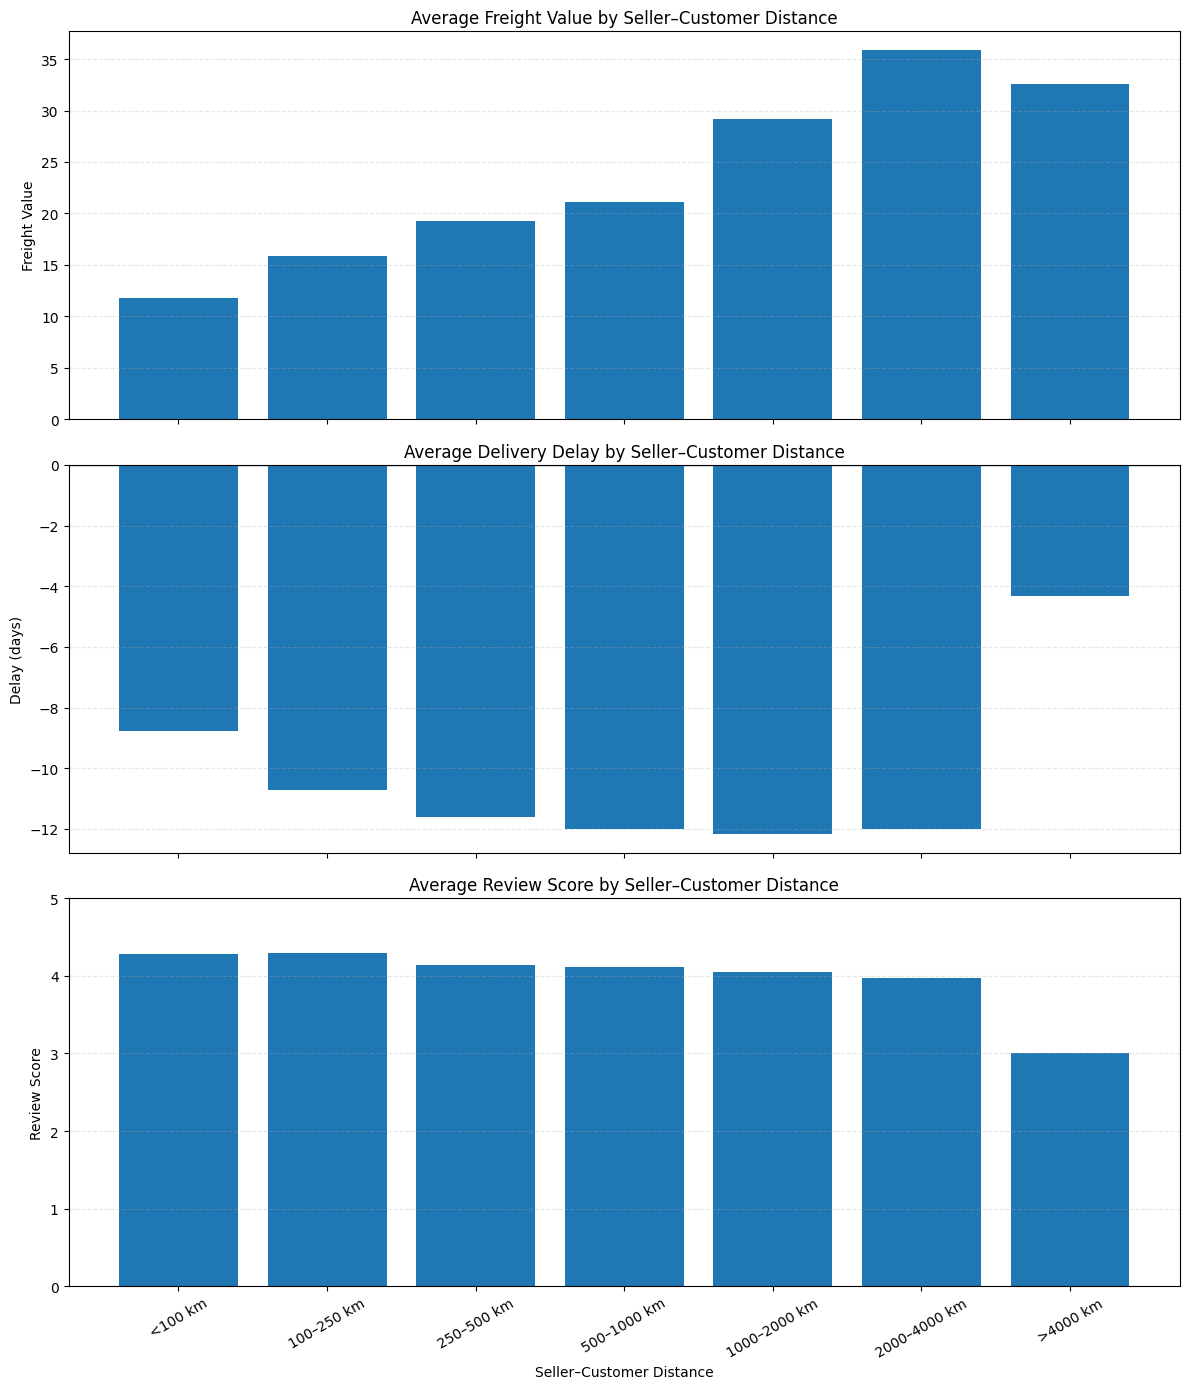

In [42]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(3, 1, figsize=(12, 14), sharex=True)

# 1. Freight cost
axes[0].bar(
    distance_freight["distance_group"],
    distance_freight["avg_freight"],
)
axes[0].set_title("Average Freight Value by Seller–Customer Distance")
axes[0].set_ylabel("Freight Value")
axes[0].grid(axis="y", linestyle = '--', alpha=0.3)

# 2. Delivery performance
axes[1].bar(
    delivery_by_distance["distance_group"],
    delivery_by_distance["avg_delay"]
)
axes[1].axhline(0, linewidth=1)
axes[1].set_title("Average Delivery Delay by Seller–Customer Distance")
axes[1].set_ylabel("Delay (days)")
axes[1].grid(axis="y", linestyle = '--', alpha=0.3)

# 3. Customer satisfaction
axes[2].bar(
    distance_reviews["distance_group"],
    distance_reviews["avg_review"]
)
axes[2].set_title("Average Review Score by Seller–Customer Distance")
axes[2].set_ylabel("Review Score")
axes[2].set_xlabel("Seller–Customer Distance")
axes[2].set_ylim(0, 5)
axes[2].grid(axis="y", linestyle = '--',alpha=0.3)

axes[2].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

### Question 4 : Product Category Performance:
How do order volume, price, and review scores differ across product categories? Are any categories notably stronger or weaker than the platform average?

A category-level table

In [43]:
query = """
WITH category_orders AS (
    SELECT
        p.product_category_name,
        COUNT(DISTINCT oi.order_id) AS order_volume,
        AVG(oi.price) AS avg_price,
        COUNT(*) AS item_count
    FROM order_items AS oi
    JOIN products AS p
        ON oi.product_id = p.product_id
    GROUP BY p.product_category_name
),

order_reviews_agg AS (
    SELECT
        order_id,
        AVG(review_score) AS avg_review_score
    FROM order_reviews
    GROUP BY order_id
),

category_reviews AS (
    SELECT
        p.product_category_name,
        AVG(r.avg_review_score) AS avg_review_score
    FROM order_items AS oi
    JOIN products AS p
        ON oi.product_id = p.product_id
    JOIN order_reviews_agg AS r
        ON oi.order_id = r.order_id
    GROUP BY p.product_category_name
)

SELECT
    COALESCE(
        ct.product_category_name_english,
        co.product_category_name,
        'Unknown'
    ) AS category,
    co.order_volume,
    co.avg_price,
    cr.avg_review_score,
    co.item_count

FROM category_orders AS co

LEFT JOIN category_reviews AS cr
    ON co.product_category_name = cr.product_category_name

LEFT JOIN category_translation AS ct
    ON co.product_category_name = ct.product_category_name

ORDER BY co.order_volume DESC;
"""

category_performance = pd.read_sql_query(query, conn)

category_performance

,category,order_volume,avg_price,avg_review_score,item_count
0,bed_bath_table,9417,93.296327,3.898334,11115
1,health_beauty,8836,130.163531,4.141827,9670
2,sports_leisure,7720,114.344285,4.107039,8641
3,computers_accessories,6689,116.513903,3.932601,7827
4,furniture_decor,6449,87.564494,3.907333,8334
...,...,...,...,...,...
69,la_cuisine,13,146.785000,4.000000,14
70,cds_dvds_musicals,12,52.142857,4.642857,14
71,fashion_childrens_clothes,8,71.231250,4.500000,8
72,pc_gamer,8,171.772222,3.333333,9


calculating reference lines

In [44]:
# Reference values
platform_avg_price = pd.read_sql_query(
    "SELECT AVG(price) AS avg_price FROM order_items",
    conn
)["avg_price"].iloc[0]

platform_avg_review = pd.read_sql_query(
    "SELECT AVG(review_score) AS avg_review FROM order_reviews",
    conn
)["avg_review"].iloc[0]

avg_category_order_volume = category_performance["order_volume"].mean()

print("Average category order volume:", avg_category_order_volume)
print("Platform average item price:", platform_avg_price)
print("Platform average review score:", platform_avg_review)

Average category order volume: 1344.1891891891892
Platform average item price: 120.65373901464713
Platform average review score: 4.08642062404257


Plotting top 15 product categories against required quantities with their respective reference lines (all categories make plot look messy)

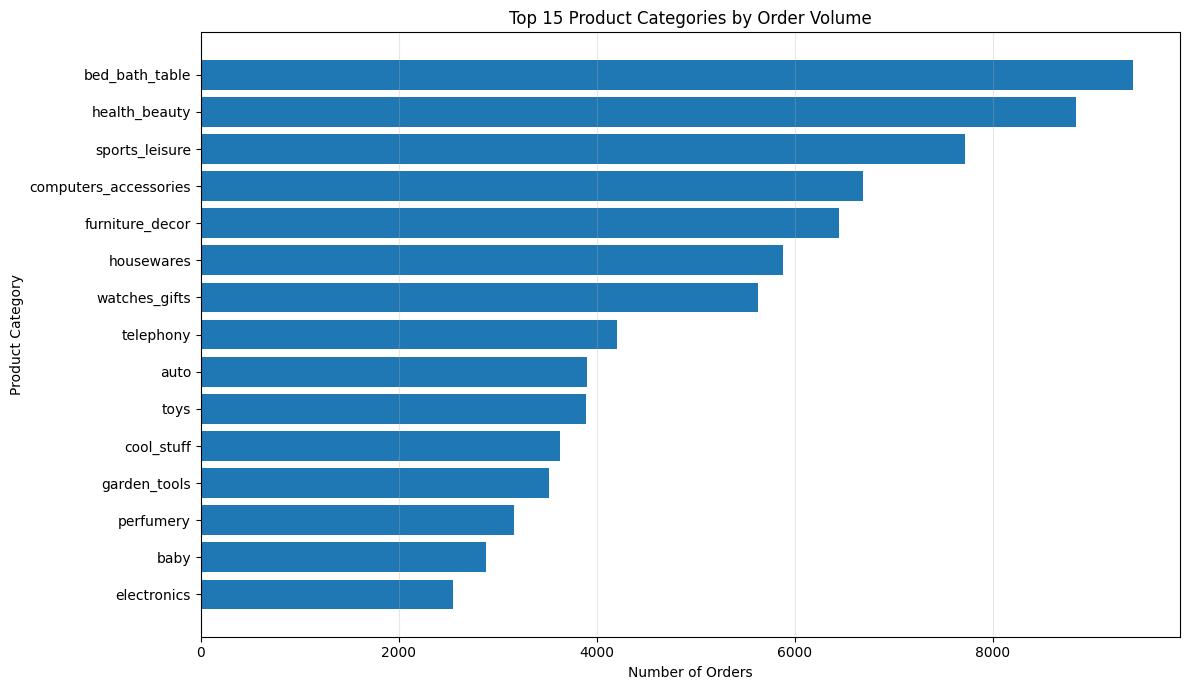

In [45]:
top_volume = (
    category_performance
    .sort_values("order_volume", ascending=False)
    .head(15)
    .sort_values("order_volume")
)

plt.figure(figsize=(12, 7))

plt.barh(
    top_volume["category"],
    top_volume["order_volume"]
)

plt.xlabel("Number of Orders")
plt.ylabel("Product Category")
plt.title("Top 15 Product Categories by Order Volume")
plt.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.show()

The reference line in the above plot is at 1,344 orders, but because the x-axis starts at 0 and the top categories extend to ~9,000, it gets visually buried among the bars.

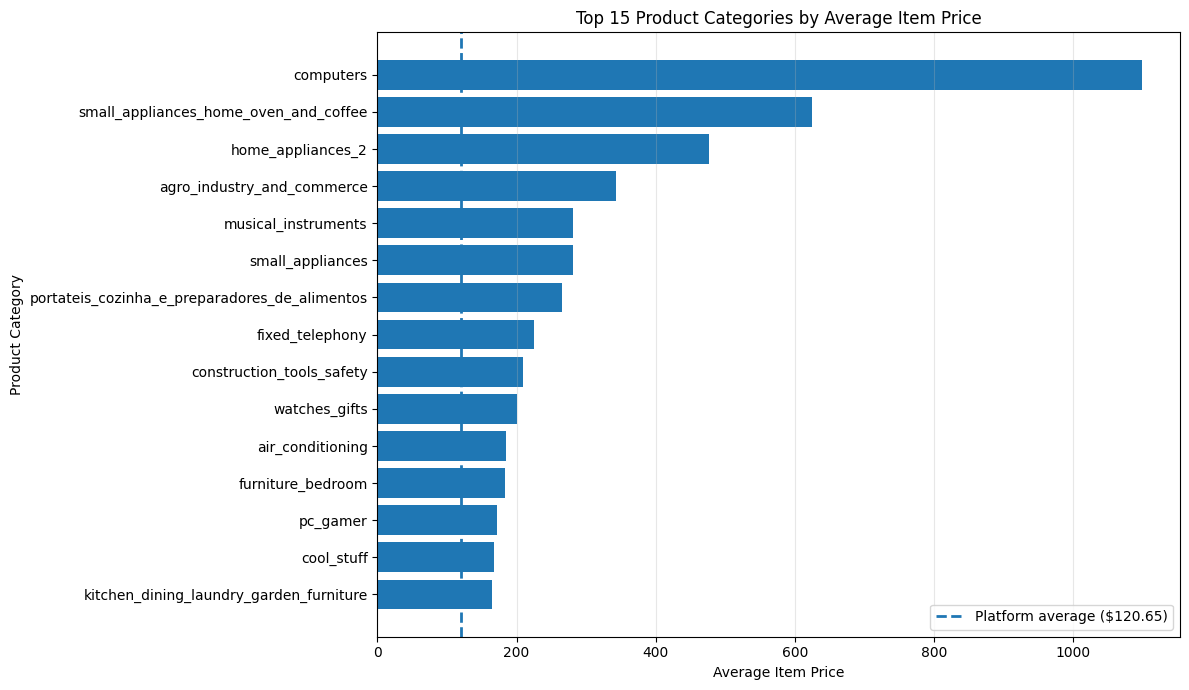

In [46]:
top_price = (
    category_performance
    [category_performance["category"] != "Unknown"]
    .sort_values("avg_price", ascending=False)
    .head(15)
    .sort_values("avg_price")
)

plt.figure(figsize=(12, 7))

plt.barh(
    top_price["category"],
    top_price["avg_price"]
)

plt.axvline(
    platform_avg_price,
    linestyle="--",
    linewidth=2,
    label=f"Platform average (${platform_avg_price:.2f})"
)

plt.xlabel("Average Item Price")
plt.ylabel("Product Category")
plt.title("Top 15 Product Categories by Average Item Price")
plt.legend()
plt.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.show()

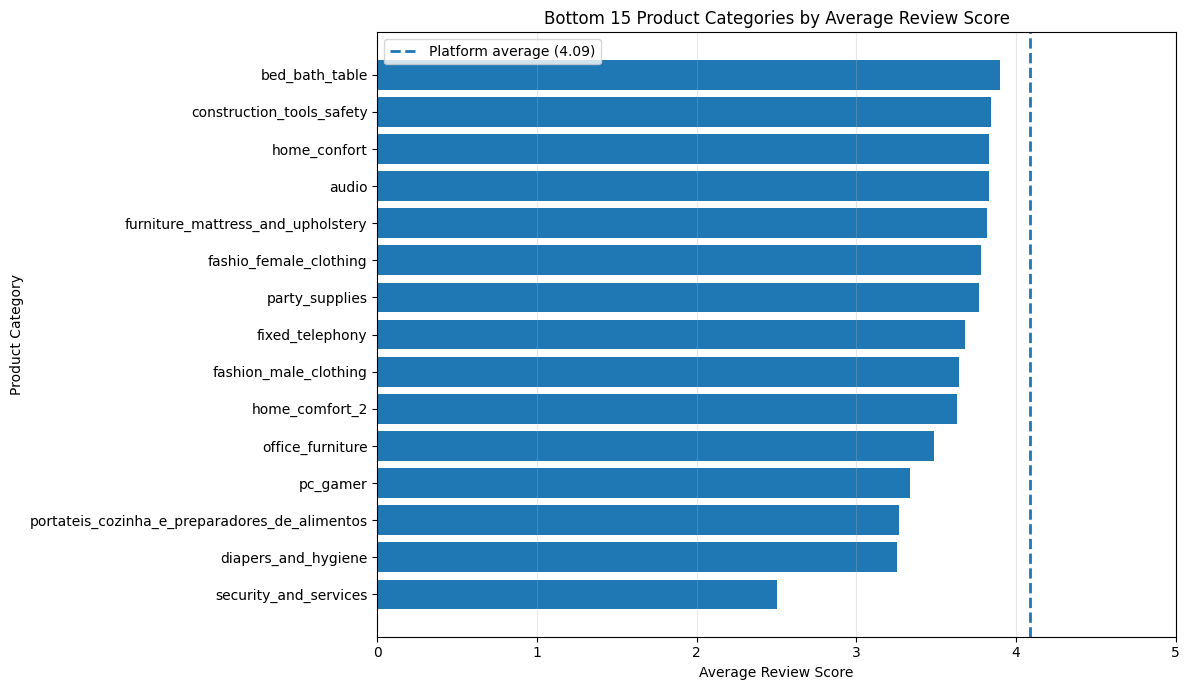

In [47]:
bottom_reviews = (
    category_performance
    [category_performance["category"] != "Unknown"]
    .sort_values("avg_review_score")
    .head(15)
    .sort_values("avg_review_score")
)

plt.figure(figsize=(12, 7))

plt.barh(
    bottom_reviews["category"],
    bottom_reviews["avg_review_score"]
)

plt.axvline(
    platform_avg_review,
    linestyle="--",
    linewidth=2,
    label=f"Platform average ({platform_avg_review:.2f})"
)

plt.xlabel("Average Review Score")
plt.ylabel("Product Category")
plt.title("Bottom 15 Product Categories by Average Review Score")
plt.xlim(0, 5)
plt.legend()
plt.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.show()

### Product Category Performance

Order volume varies substantially across product categories, with categories such as **bed & bath table, health & beauty, and sports & leisure** accounting for the highest number of orders. This indicates that demand is concentrated in a relatively small number of categories.

Average item prices also differ considerably across categories. **Computers** have the highest average price by a large margin, followed by several appliance-related categories. In comparison, many of the high-volume categories have average prices closer to or below the platform-wide average of approximately **$120.65**. This suggests that high order volume does not necessarily correspond to high-priced products.

Customer satisfaction is generally high across categories, with the platform-wide average review score around **4.09/5**. However, several categories fall noticeably below this benchmark, particularly **security & services, diapers & hygiene, and kitchen-related categories**. These categories may warrant further investigation to determine whether lower satisfaction is associated with product quality, delivery experience, or other factors.

Overall, **category performance differs across demand, price, and customer satisfaction**. Categories with high order volume are not necessarily the most expensive or the highest-rated, suggesting that marketplace strength depends on different factors rather than a single performance metric.

## Question 4 :Payment Behavior:
How do payment type and installment choices relate to order value, and do they appear connected to anything else in the customer’s experience?

we try to build an order-level analytical table:

order_id → total order value + payment type(s) + installments + review score

In [48]:
query = """
WITH order_value AS (
    SELECT
        order_id,
        SUM(price + freight_value) AS order_value
    FROM order_items
    GROUP BY order_id
),

payment_summary AS (
    SELECT
        order_id,
        COUNT(*) AS payment_count,
        SUM(payment_value) AS total_payment_value,
        MAX(payment_installments) AS max_installments,
        GROUP_CONCAT(DISTINCT payment_type) AS payment_types
    FROM order_payments
    GROUP BY order_id
),

review_summary AS (
    SELECT
        order_id,
        AVG(review_score) AS review_score
    FROM order_reviews
    GROUP BY order_id
)

SELECT
    o.order_id,
    ov.order_value,
    ps.payment_count,
    ps.total_payment_value,
    ps.max_installments,
    ps.payment_types,
    rs.review_score
FROM orders AS o
JOIN order_value AS ov
    ON o.order_id = ov.order_id
JOIN payment_summary AS ps
    ON o.order_id = ps.order_id
LEFT JOIN review_summary AS rs
    ON o.order_id = rs.order_id;
"""

payment_analysis = pd.read_sql_query(query, conn)

payment_analysis.head()

,order_id,order_value,payment_count,total_payment_value,max_installments,payment_types,review_score
0,00010242fe8c5a6d1ba2dd792cb16214,72.19,1,72.19,2,credit_card,5.0
1,00018f77f2f0320c557190d7a144bdd3,259.83,1,259.83,3,credit_card,4.0
2,000229ec398224ef6ca0657da4fc703e,216.87,1,216.87,5,credit_card,5.0
3,00024acbcdf0a6daa1e931b038114c75,25.78,1,25.78,2,credit_card,4.0
4,00042b26cf59d7ce69dfabb4e55b4fd9,218.04,1,218.04,3,credit_card,5.0


This gives us one row per order.

In [49]:
installment_summary = (
    payment_analysis
    .assign(
        installment_group=pd.cut(
            payment_analysis["max_installments"],
            bins=[-1, 1, 3, 6, 9, 12, np.inf],
            labels=[
                "1",
                "2–3",
                "4–6",
                "7–9",
                "10–12",
                "13+"
            ]
        )
    )
    .groupby("installment_group", observed=True)
    .agg(
        avg_order_value=("order_value", "mean"),
        median_order_value=("order_value", "median"),
        orders=("order_id", "count")
    )
    .reset_index()
)

installment_summary

,installment_group,avg_order_value,median_order_value,orders
0,1,120.562934,79.33,47825
1,2–3,136.033157,111.76,22662
2,4–6,182.626597,128.62,16097
3,7–9,268.855604,181.10,6483
4,10–12,412.897638,238.17,5414
5,13+,416.005598,248.11,184


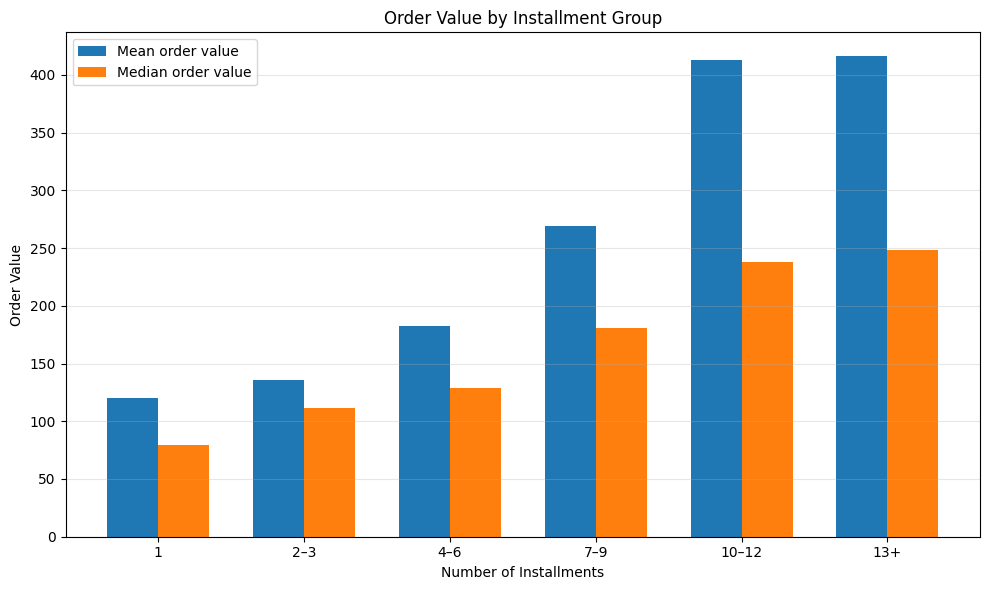

In [50]:
plt.figure(figsize=(10, 6))

x = np.arange(len(installment_summary))
width = 0.35

plt.bar(
    x - width/2,
    installment_summary["avg_order_value"],
    width,
    label="Mean order value"
)

plt.bar(
    x + width/2,
    installment_summary["median_order_value"],
    width,
    label="Median order value"
)

plt.xlabel("Number of Installments")
plt.ylabel("Order Value")
plt.title("Order Value by Installment Group")
plt.xticks(x, installment_summary["installment_group"])
plt.legend()
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

In [51]:
payment_type_summary = (
    payment_analysis
    .assign(
        payment_type=payment_analysis["payment_types"].replace({
            "credit_card": "Credit Card",
            "boleto": "Boleto",
            "voucher": "Voucher",
            "debit_card": "Debit Card",
            "credit_card,voucher": "Credit Card + Voucher",
            "debit_card,credit_card": "Debit Card + Credit Card"
        })
    )
    .groupby("payment_type")
    .agg(
        avg_order_value=("order_value", "mean"),
        median_order_value=("order_value", "median"),
        avg_installments=("max_installments", "mean"),
        orders=("order_id", "count"),
        avg_review_score=("review_score", "mean")
    )
    .reset_index()
    .sort_values("avg_order_value", ascending=False)
)

payment_type_summary

,payment_type,avg_order_value,median_order_value,avg_installments,orders,avg_review_score
1,Credit Card,166.603299,109.345,3.548384,73764,4.104602
4,Debit Card + Credit Card,152.820000,152.820,3.000000,1,NaN
2,Credit Card + Voucher,150.265863,102.215,2.180144,2226,4.092618
0,Boleto,144.908753,93.835,1.000000,19614,4.107108
3,Debit Card,141.518237,89.300,1.000000,1520,4.180647
5,Voucher,105.254149,70.380,1.000000,1540,4.045524


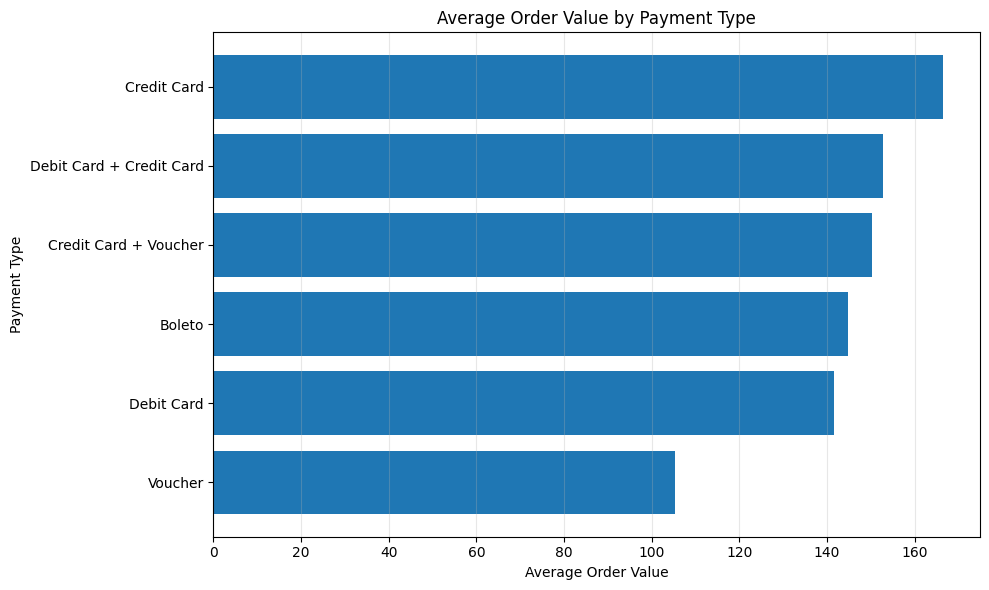

In [52]:
plt.figure(figsize=(10, 6))

plot_data = payment_type_summary.sort_values("avg_order_value")

plt.barh(
    plot_data["payment_type"],
    plot_data["avg_order_value"]
)

plt.xlabel("Average Order Value")
plt.ylabel("Payment Type")
plt.title("Average Order Value by Payment Type")
plt.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.show()

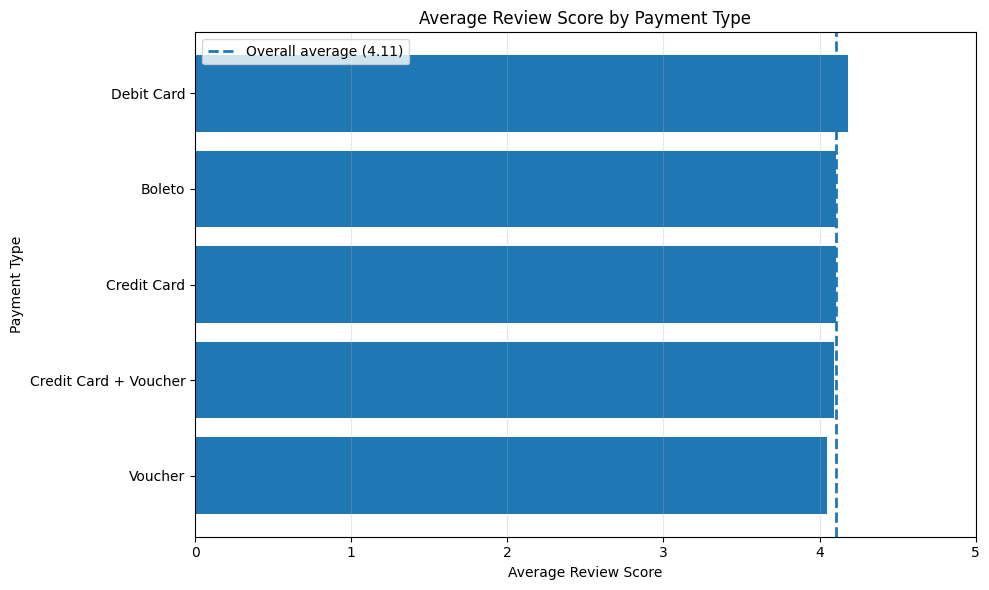

In [53]:
plt.figure(figsize=(10, 6))

plot_data = payment_type_summary.sort_values("avg_review_score")

plt.barh(
    plot_data["payment_type"],
    plot_data["avg_review_score"]
)

plt.axvline(
    payment_analysis["review_score"].mean(),
    linestyle="--",
    linewidth=2,
    label=f"Overall average ({payment_analysis['review_score'].mean():.2f})"
)

plt.xlabel("Average Review Score")
plt.ylabel("Payment Type")
plt.title("Average Review Score by Payment Type")
plt.xlim(0, 5)
plt.legend()
plt.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.show()

### Payment Behavior

Payment behavior shows a clear relationship with order value. Orders paid using **credit cards** have the highest average order value among the major payment methods, at approximately $166.60, while  voucher- only payments have the lowest at approximately $105.25. Credit card payments also account for the vast majority of orders, making them the dominant payment method on the platform.

Order value also generally increases with the number of installments. The median order value rises from approximately $80 for single-payment orders to around $250 for orders with 13 or more installments. This suggests that installment payments are primarily associated with higher-value purchases. However, the relationship should be interpreted as an association rather than a causal effect, particularly because the higher-installment groups contain fewer observations and are more variable.

Payment method appears to have little relationship with customer satisfaction. Average review scores remain close to the overall average of 4.11 across the major payment types, ranging from approximately 4.05 for voucher payments to 4.18 for debit-card payments. Thus, while payment behavior is strongly associated with order value, it does not appear to substantially affect the customer's review experience.

Overall, payment choice is more closely related to transaction value than to customer satisfaction, with credit cards and installment payments being particularly associated with higher-value purchases.

#Question 6 : Root Cause Analysis:
Identify the most important factors associated with low review scores on this platform. Use evidence to distinguish between factors that appear to be primary drivers and factors that appear to be secondary or contributing. You are not expected to prove a single cause; more than one factor likely contributes.

### Root Cause Analysis

According to the results of the analysis, **performance in the area of delivery is the key feature related to low review scores**. The correlation between review score and delay in delivery is negative: Pearson and Spearman correlations equal approximately **−0.27** and **−0.18**, respectively. More importantly, the connection between delivery delay and review score is nonlinear: review scores stay high for products delivered early or according to schedule, but significantly drop if delivery is delayed for several days. Thus, significant delivery delay can be considered a primary cause of low reviews even though no causality was proven.

**Product category seems to be a secondary factor in determining satisfaction of customers**. Scores for reviews tend to differ depending on the category of the purchased product, with some categories being below the average of **4.09**. It is possible to suggest that a product category itself is related to customer satisfaction, although this connection might be caused by product quality or expectations of the buyer. Nevertheless, differences in scores for categories are much smaller than in the case of severe delivery delays.

**Geographical distance can be considered a contributor to low reviews rather than a primary cause of them**. On average, review scores decrease as the distance between the seller and the customer grows from about **4.27 for orders less than 100 km to 3.98 for orders between 2000 and 4000 km**. However, larger distances were not related to larger delays compared to the delivery schedule, thus suggesting a weak connection with customer satisfaction.

Finally, **there seems to be almost no connection between payment methods and low review scores**. The average scores of reviews for all major types of payment remain close to the platform average regardless of considerable difference in transaction amount and installment payments. Hence, there seems to be much more connection between transaction size and payment type than between payment type and customer satisfaction.

To conclude, **delivery delays seem to be the most significant factor connected to low review scores, while product category and distance between seller and buyer can be considered secondary contributors**. Payment methods seem to have no significant connection to customer satisfaction.

## 📊 Executive Dashboard — Interactive (Plotly)

A single business-facing summary for Olist operations and customer-experience stakeholders. Every chart below **reuses the DataFrames already computed earlier in this notebook** (`result_over_months`, `delay_review`, `category_performance`, `payment_analysis`, `distance_freight`, `delivery_by_distance`, `distance_reviews`, etc.) — no analysis is duplicated here. Charts are interactive: hover for exact values, click legend entries to isolate a series, and use the buttons on the category chart to switch views.

In [54]:
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
from IPython.display import Markdown, display


### KPI Summary

In [55]:
# --- KPI values (all derived from results already computed above, no re-analysis) ---
total_orders   = int(result_over_months["order_volume"].sum())
total_revenue  = float(result_over_months["revenue"].sum())
avg_review_kpi = float(platform_avg_review)
on_time_rate   = float((delivery["delivery_delay_days"] <= 0).mean() * 100)
avg_freight_kpi = float(order_items["freight_value"].mean())

kpi_fig = make_subplots(rows=1, cols=5, specs=[[{"type": "indicator"}] * 5])

kpi_fig.add_trace(go.Indicator(
    mode="number", value=total_orders,
    number={"valueformat": ",.0f"},
    title={"text": "Total Orders"}
), row=1, col=1)

kpi_fig.add_trace(go.Indicator(
    mode="number", value=total_revenue,
    number={"prefix": "$", "valueformat": ",.0f"},
    title={"text": "Total Revenue"}
), row=1, col=2)

kpi_fig.add_trace(go.Indicator(
    mode="number", value=avg_review_kpi,
    number={"valueformat": ".2f"},
    title={"text": "Avg Review Score (/5)"}
), row=1, col=3)

kpi_fig.add_trace(go.Indicator(
    mode="number", value=on_time_rate,
    number={"suffix": "%", "valueformat": ".1f"},
    title={"text": "On-Time Delivery Rate"}
), row=1, col=4)

kpi_fig.add_trace(go.Indicator(
    mode="number", value=avg_freight_kpi,
    number={"prefix": "$", "valueformat": ".2f"},
    title={"text": "Avg Freight / Item"}
), row=1, col=5)

kpi_fig.update_layout(
    height=220, margin=dict(t=70, b=20, l=20, r=20),
    title_text="Olist Platform — Key Performance Indicators", title_x=0.5
)
kpi_fig.show()


### Marketplace Trends Over Time

In [56]:
trend_fig = make_subplots(
    rows=2, cols=1, shared_xaxes=True,
    specs=[[{"secondary_y": True}], [{"secondary_y": False}]],
    row_heights=[0.6, 0.4], vertical_spacing=0.1,
    subplot_titles=("Order Volume & Revenue", "Average Review Score")
)

trend_fig.add_trace(go.Bar(
    x=result_over_months["month"], y=result_over_months["order_volume"],
    name="Order Volume", marker_color="#636EFA", opacity=0.5
), row=1, col=1, secondary_y=False)

trend_fig.add_trace(go.Scatter(
    x=result_over_months["month"], y=result_over_months["order_volume_ma"],
    name="Order Volume (3-mo avg)", line=dict(color="#636EFA", width=3)
), row=1, col=1, secondary_y=False)

trend_fig.add_trace(go.Scatter(
    x=result_over_months["month"], y=result_over_months["revenue"],
    name="Revenue", line=dict(color="#00CC96", width=1, dash="dot")
), row=1, col=1, secondary_y=True)

trend_fig.add_trace(go.Scatter(
    x=result_over_months["month"], y=result_over_months["revenue_ma"],
    name="Revenue (3-mo avg)", line=dict(color="#00CC96", width=3)
), row=1, col=1, secondary_y=True)

trend_fig.add_trace(go.Scatter(
    x=result_over_months["month"], y=result_over_months["avg_review_score"],
    name="Avg Review Score", line=dict(color="#EF553B", width=1, dash="dot"), showlegend=False
), row=2, col=1)

trend_fig.add_trace(go.Scatter(
    x=result_over_months["month"], y=result_over_months["review_score_ma"],
    name="Avg Review Score (3-mo avg)", line=dict(color="#EF553B", width=3)
), row=2, col=1)

trend_fig.add_hline(
    y=platform_avg_review, line_dash="dash", line_color="gray",
    annotation_text=f"Platform avg ({platform_avg_review:.2f})",
    row=2, col=1
)

trend_fig.update_yaxes(title_text="Orders", row=1, col=1, secondary_y=False)
trend_fig.update_yaxes(title_text="Revenue ($)", row=1, col=1, secondary_y=True)
trend_fig.update_yaxes(title_text="Review Score", range=[1, 5], row=2, col=1)
trend_fig.update_xaxes(title_text="Month", row=2, col=1)

trend_fig.update_layout(
    height=680, title_text="Marketplace Performance Over Time", title_x=0.5,
    legend=dict(orientation="h", yanchor="bottom", y=-0.18, x=0)
)
trend_fig.show()


### Delivery Delay vs. Customer Satisfaction

In [57]:
delay_order = ["< -15 days", "-15 to -8", "-7 to -1", "On time", "1–3 days late",
               "4–7 days late", "8–15 days late", "16–30 days late", "> 30 days late"]
delay_review_plot = delay_review.set_index("delay_group").reindex(delay_order).reset_index()
spearman_delay_review = delivery_reviews["delivery_delay_days"].corr(delivery_reviews["review_score"], method="spearman")

delay_fig = make_subplots(specs=[[{"secondary_y": True}]])

delay_fig.add_trace(go.Bar(
    x=delay_review_plot["delay_group"], y=delay_review_plot["avg_review_score"],
    name="Avg Review Score", marker_color="#636EFA"
), secondary_y=False)

delay_fig.add_trace(go.Scatter(
    x=delay_review_plot["delay_group"], y=delay_review_plot["order_count"],
    name="Order Count", line=dict(color="#EF553B", width=2), mode="lines+markers"
), secondary_y=True)

delay_fig.add_hline(
    y=platform_avg_review, line_dash="dash", line_color="gray",
    annotation_text=f"Platform avg review ({platform_avg_review:.2f})",
    secondary_y=False
)

delay_fig.update_yaxes(title_text="Avg Review Score", range=[1, 5], secondary_y=False)
delay_fig.update_yaxes(title_text="Order Count", secondary_y=True)
delay_fig.update_xaxes(title_text="Delivery Timing (vs. Estimate)", tickangle=20)
delay_fig.update_layout(
    height=480,
    title_text=f"Review Score Drops Once Deliveries Run Late (Spearman ρ = {spearman_delay_review:.2f})",
    title_x=0.5, legend=dict(orientation="h", yanchor="bottom", y=-0.3)
)
delay_fig.show()


### Product Category Performance

In [58]:
cat_fig = go.Figure()

cat_fig.add_trace(go.Bar(
    x=top_volume["order_volume"], y=top_volume["category"], orientation="h",
    marker_color="#636EFA", name="Order Volume", visible=True
))
cat_fig.add_trace(go.Bar(
    x=top_price["avg_price"], y=top_price["category"], orientation="h",
    marker_color="#00CC96", name="Avg Price", visible=False
))
cat_fig.add_trace(go.Bar(
    x=bottom_reviews["avg_review_score"], y=bottom_reviews["category"], orientation="h",
    marker_color="#EF553B", name="Avg Review Score", visible=False
))

cat_fig.update_layout(
    height=540, title_text="Top 15 Categories by Order Volume", title_x=0.5,
    xaxis_title="Number of Orders",
    updatemenus=[dict(
        type="buttons", direction="right", x=0.5, xanchor="center", y=1.15, yanchor="top",
        buttons=[
            dict(label="Order Volume", method="update",
                 args=[{"visible": [True, False, False]},
                       {"title": "Top 15 Categories by Order Volume", "xaxis": {"title": "Number of Orders"}}]),
            dict(label="Avg Price", method="update",
                 args=[{"visible": [False, True, False]},
                       {"title": "Top 15 Categories by Average Item Price", "xaxis": {"title": "Average Price ($)"}}]),
            dict(label="Lowest Avg Review Score", method="update",
                 args=[{"visible": [False, False, True]},
                       {"title": "Bottom 15 Categories by Average Review Score", "xaxis": {"title": "Avg Review Score", "range": [0, 5]}}]),
        ]
    )]
)
cat_fig.show()


### Payment Behavior

In [59]:
pay_fig = make_subplots(
    rows=1, cols=2,
    subplot_titles=("Order Value by Payment Type", "Order Value by Installment Plan")
)

pay_fig.add_trace(go.Bar(
    x=payment_type_summary["payment_type"], y=payment_type_summary["avg_order_value"],
    marker=dict(color=payment_type_summary["avg_review_score"], colorscale="RdYlGn", cmin=1, cmax=5,
                colorbar=dict(title="Avg Review", x=0.44)),
    text=payment_type_summary["orders"].apply(lambda n: f"{n:,} orders"),
    name="Avg Order Value"
), row=1, col=1)

pay_fig.add_trace(go.Scatter(
    x=installment_summary["installment_group"], y=installment_summary["avg_order_value"],
    mode="lines+markers",
    marker=dict(size=(installment_summary["orders"] / installment_summary["orders"].max() * 30 + 8)),
    line=dict(color="#636EFA"), name="Avg Order Value"
), row=1, col=2)

pay_fig.update_yaxes(title_text="Avg Order Value ($)", row=1, col=1)
pay_fig.update_yaxes(title_text="Avg Order Value ($)", row=1, col=2)
pay_fig.update_xaxes(title_text="Payment Type", tickangle=15, row=1, col=1)
pay_fig.update_xaxes(title_text="Installments", row=1, col=2)
pay_fig.update_layout(height=500, title_text="Payment Behavior & Order Value", title_x=0.5, showlegend=False)
pay_fig.show()


### Geographic & Freight Insights

In [60]:
dist_order = ["<100 km", "100–250 km", "250–500 km", "500–1000 km", "1000–2000 km", "2000–4000 km", ">4000 km"]

df_f = distance_freight.set_index("distance_group").reindex(dist_order).reset_index()
df_d = delivery_by_distance.set_index("distance_group").reindex(dist_order).reset_index()
df_r = distance_reviews.set_index("distance_group").reindex(dist_order).reset_index()

geo_fig = make_subplots(
    rows=1, cols=3,
    subplot_titles=("Avg Freight Value", "Avg Delivery Delay (days)", "Avg Review Score")
)

geo_fig.add_trace(go.Bar(x=df_f["distance_group"], y=df_f["avg_freight"], marker_color="#636EFA", name="Avg Freight"), row=1, col=1)
geo_fig.add_trace(go.Bar(x=df_d["distance_group"], y=df_d["avg_delay"], marker_color="#00CC96", name="Avg Delay"), row=1, col=2)
geo_fig.add_trace(go.Bar(x=df_r["distance_group"], y=df_r["avg_review"], marker_color="#EF553B", name="Avg Review"), row=1, col=3)

geo_fig.add_hline(y=0, line_dash="dash", line_color="gray", row=1, col=2)
geo_fig.add_hline(y=platform_avg_review, line_dash="dash", line_color="gray", row=1, col=3)

geo_fig.update_yaxes(title_text="Freight ($)", row=1, col=1)
geo_fig.update_yaxes(title_text="Delay (days, + = late)", row=1, col=2)
geo_fig.update_yaxes(title_text="Review Score", range=[0, 5], row=1, col=3)
for c in [1, 2, 3]:
    geo_fig.update_xaxes(title_text="Seller–Customer Distance", tickangle=30, row=1, col=c)

geo_fig.update_layout(
    height=480, title_x=0.5, showlegend=False,
    title_text="Distance Drives Freight Cost Far More Than Delivery Speed or Satisfaction"
)
geo_fig.show()


### Key Findings

In [61]:
top_cat_row = category_performance.sort_values("order_volume", ascending=False).iloc[0]
worst_cat_row = bottom_reviews.sort_values("avg_review_score", ascending=True).iloc[0]
best_pay_row = payment_type_summary.sort_values("avg_order_value", ascending=False).iloc[0]
near_review = df_r.iloc[0]["avg_review"]
far_review = df_r.iloc[-2]["avg_review"]  # second-to-last bucket (>4000km has n=4, too small to be reliable)

findings_md = f"""
- **Growth has been strong but is flattening.** Monthly order volume and revenue rose steadily through the observed period, with revenue tracking order volume closely (same growth, not higher-value baskets) — and growth visibly slowed toward the end of 2018.
- **Delivery lateness is the single strongest driver of dissatisfaction.** Average review score is essentially flat (~4.6–4.7) for orders delivered on time or early, then falls off a cliff once deliveries run late (Spearman ρ = {spearman_delay_review:.2f} at the order level, but the grouped effect is large and consistent).
- **Geography drives cost, not experience.** Seller–customer distance has a strong, monotonic relationship with freight cost, but only a mild relationship with review scores ({near_review:.2f} for <100 km vs. {far_review:.2f} for 2,000–4,000 km) and essentially none with delivery lateness — Olist's logistics network absorbs distance well.
- **'{top_cat_row['category']}' leads order volume** ({int(top_cat_row['order_volume']):,} orders), while categories like **'{worst_cat_row['category']}'** sit well below the platform's average review score ({platform_avg_review:.2f}) — a targeted quality-control review of the weakest categories is likely to move the needle more than platform-wide changes.
- **Payment method correlates with basket size, not satisfaction.** **{best_pay_row['payment_type']}** carries the highest average order value (${best_pay_row['avg_order_value']:.2f}), and review scores are comparable across payment types — installments scale with order value but don't appear to hurt satisfaction.
- **Bottom line:** delivery timing — not distance, price, category, or payment method — is the most actionable lever for improving customer satisfaction on Olist.
"""

display(Markdown(findings_md))



- **Growth has been strong but is flattening.** Monthly order volume and revenue rose steadily through the observed period, with revenue tracking order volume closely (same growth, not higher-value baskets) — and growth visibly slowed toward the end of 2018.
- **Delivery lateness is the single strongest driver of dissatisfaction.** Average review score is essentially flat (~4.6–4.7) for orders delivered on time or early, then falls off a cliff once deliveries run late (Spearman ρ = -0.18 at the order level, but the grouped effect is large and consistent).
- **Geography drives cost, not experience.** Seller–customer distance has a strong, monotonic relationship with freight cost, but only a mild relationship with review scores (4.28 for <100 km vs. 3.98 for 2,000–4,000 km) and essentially none with delivery lateness — Olist's logistics network absorbs distance well.
- **'bed_bath_table' leads order volume** (9,417 orders), while categories like **'security_and_services'** sit well below the platform's average review score (4.09) — a targeted quality-control review of the weakest categories is likely to move the needle more than platform-wide changes.
- **Payment method correlates with basket size, not satisfaction.** **Credit Card** carries the highest average order value ($166.60), and review scores are comparable across payment types — installments scale with order value but don't appear to hurt satisfaction.
- **Bottom line:** delivery timing — not distance, price, category, or payment method — is the most actionable lever for improving customer satisfaction on Olist.
